## Figure 1h, i
## Supplementary Figure 2a, b, 8, 14

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, kstest, pearsonr, spearmanr, ttest_ind, permutation_test, gmean, friedmanchisquare
from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter1d

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests
# from statannot import add_stat_annotation
from statannotations.Annotator import Annotator

from itertools import combinations, product
import math
from umap import UMAP
import networkx as nx

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# loading variables

# ABO Neuropixels
with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
    list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
    list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
    list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
    list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
    list_slopes_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_all_att_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
    list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
    list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()

    sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
    sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
    sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
    sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()
    
with open('resp_matrix_ep_sg_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_sg_all = dc(resp_matrix_ep_RS_all['list_rate_sg_all'])
    list_slopes_sg_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_sg_all_att_loglog'].copy()
    list_slopes_sg_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_sg_all_an_loglog'].copy()
    list_sg_ori = dc(resp_matrix_ep_RS_all['list_sg_ori'])
    list_sg_sf = dc(resp_matrix_ep_RS_all['list_sg_sf'])
    list_sg_ph = dc(resp_matrix_ep_RS_all['list_sg_ph'])
    sg_triplets = resp_matrix_ep_RS_all['sg_triplets'].copy()
    
with open('resp_matrix_ep_dg75_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_dg75_all = resp_matrix_ep_RS_all['list_rate_dg75_all'].copy()
    list_rate_dg75_250_all = resp_matrix_ep_RS_all['list_rate_dg75_250_all'].copy()
    list_slopes_dg75_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_dg75_all_att_loglog'].copy()
    list_slopes_dg75_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_dg75_all_an_loglog'].copy()
    list_slopes_dg75_250_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_dg75_250_all_att_loglog'].copy()
    list_slopes_dg75_250_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_dg75_250_all_an_loglog'].copy()
    list_dg75_ori = resp_matrix_ep_RS_all['list_dg75_ori'].copy()
    list_dg75_ct = resp_matrix_ep_RS_all['list_dg75_ct'].copy()
    dg75_pairs = resp_matrix_ep_RS_all['dg75_pairs'].copy()

    list_sess_ids = resp_matrix_ep_RS_all['list_sess_ids'].copy()
    brain_observatory_sessid = resp_matrix_ep_RS_all['brain_observatory_sessid'].copy()

with open('resp_matrix_ep_diffwin_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_diffwin_trunc_all = resp_matrix_ep_RS_all['list_rate_diffwin_trunc_all'].copy()
    list_rate_diffwin_part_all = resp_matrix_ep_RS_all['list_rate_diffwin_part_all'].copy()
    list_slopes_diffwin_trunc_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_diffwin_trunc_all_att_loglog'].copy()
    list_slopes_diffwin_trunc_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_diffwin_trunc_all_an_loglog'].copy()
    list_slopes_diffwin_part_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_diffwin_part_all_att_loglog'].copy()
    list_slopes_diffwin_part_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_diffwin_part_all_an_loglog'].copy()
    list_wins = resp_matrix_ep_RS_all['list_wins'].copy()
    latency = resp_matrix_ep_RS_all['latency']
    stride = resp_matrix_ep_RS_all['stride']

with open('resp_matrix_ep_spt_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_spt_diffwin_all = resp_matrix_ep_RS_all['list_rate_spt_diffwin_all'].copy()
    list_slopes_spt_diffwin_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_spt_diffwin_all_an_loglog'].copy()
    list_wins_spt = resp_matrix_ep_RS_all['list_wins_spt'].copy()

with open('invalid_unit_sess.pickle', 'rb') as f:
    invalid_unit_sess = pickle.load(f)

    list_invalid_units_visp = invalid_unit_sess['list_invalid_units_visp'].copy()
    list_invalid_units_HVA = invalid_unit_sess['list_invalid_units_HVA'].copy()
    list_invalid_sess_visp = invalid_unit_sess['list_invalid_sess_visp'].copy()
    list_invalid_sess_HVA = invalid_unit_sess['list_invalid_sess_HVA'].copy()
    sess_inds_mapBO = invalid_unit_sess['sess_inds_mapBO'].copy()

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [6]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [7]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, 
                          gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, fontsize=10, ignore_ns=True):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    if ignore_ns:
        pval_thres = 0.05
    else:
        pval_thres = 1
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        if pval <= pval_thres:
            x1, x2 = min(idx1, idx2), max(idx1, idx2)
            
            # Check Data Height
            data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
            
            # Check Interval Height
            if x1 < x2:
                interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
            else:
                interval_peak = 0
                
            # Determine drawing height
            # Must clear both the data and the previous bars below it
            y_line = np.nanmax([data_peak, interval_peak]) + clearance
            
            # if adjacent bars have same height, move up the second one
            if com_ind >= 1:
                idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
                x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
                pval_prev = sorted_p_values[com_ind-1]
                if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev and pval_prev <= pval_thres:
                    y_line_prev = interval_skyline[x1_prev] - text_height
                    if np.isclose(y_line, y_line_prev):
                        y_line += clearance * bottomline_offset

            # Draw Line
            x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
            line_x = [x_pos1, x_pos2]
            line_y = [y_line, y_line]
            ax.plot(line_x, line_y, lw=1.5, c='k')
        
            # Add Text
            text_y = y_line + (clearance * gap_below_text)
            if pval < 0.001:
                asterisk = '***'
            elif pval < 0.01:
                asterisk = '**'
            elif pval < 0.05:
                asterisk = '*'
            else:
                asterisk = f'p={pval:.2f}'
            ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color='k')
            
            # Update Interval Skyline
            new_height = y_line + text_height
            for k in range(x1, x2):
                interval_skyline[k] = new_height

    return ax

In [8]:
def heatmap_cbar(data, figsize_hm=(4, 4), figsize_all=(5, 4),
                 cmap="rocket", vmin=None, vmax=None, heatmap_kws=None, cbar_kws=None):
    """
    Make figsize=figsize_all where:
      - heatmap matches seaborn heatmap in figsize_hm with cbar=False
      - colorbar width + gap match seaborn heatmap in figsize_all with cbar=True
    """
    heatmap_kws = {} if heatmap_kws is None else dict(heatmap_kws)
    cbar_kws    = {} if cbar_kws is None else dict(cbar_kws)

    if vmin is None: vmin = np.nanmin(data)
    if vmax is None: vmax = np.nanmax(data)

    def bbox_in_inches(fig, ax):
        fig.canvas.draw()
        b = ax.get_position() # figure-fraction
        fw, fh = fig.get_size_inches()
        return (b.x0 * fw, b.y0 * fh, b.width * fw, b.height * fh)

    # Reference A: figsize_hm, cbar=False → heatmap axes box
    figA, axA = plt.subplots(figsize=figsize_hm)
    sns.heatmap(data, ax=axA, cbar=False, cmap=cmap, vmin=vmin, vmax=vmax, **heatmap_kws)
    hm_x0, hm_y0, hm_w, hm_h = bbox_in_inches(figA, axA)
    plt.close(figA)

    # Reference B: figsize_all, cbar=True → colorbar width + gap
    figB, axB = plt.subplots(figsize=figsize_all)
    hmB = sns.heatmap(data, ax=axB, cbar=True, cmap=cmap, vmin=vmin, vmax=vmax,
                      cbar_kws=cbar_kws, **heatmap_kws)
    caxB = hmB.figure.axes[-1]
    hmB_x0, hmB_y0, hmB_w, hmB_h = bbox_in_inches(figB, axB)
    cbB_x0, cbB_y0, cbB_w, cbB_h = bbox_in_inches(figB, caxB)
    gap = cbB_x0 - (hmB_x0 + hmB_w) # inches
    cbar_w = cbB_w # inches
    plt.close(figB)

    # Final: figsize_all with manual axes placement
    fig = plt.figure(figsize=figsize_all)
    fw, fh = fig.get_size_inches()

    ax_hm = fig.add_axes([hm_x0/fw, hm_y0/fh, hm_w/fw, hm_h/fh])

    cb_x0 = hm_x0 + hm_w + gap
    ax_cb = fig.add_axes([cb_x0/fw, hm_y0/fh, cbar_w/fw, hm_h/fh])

    sns.heatmap(data, ax=ax_hm, cbar=True, cbar_ax=ax_cb, cmap=cmap,
                vmin=vmin, vmax=vmax, cbar_kws=cbar_kws, **heatmap_kws)

    return fig, ax_hm, ax_cb

In [9]:
# Function to compute cosine similarity
def cos_sim(x, y):
    # x and y are 1D vectors

    # Remove NaN
    x, y = np.array(x), np.array(y)
    bool_notnan = np.logical_and(~np.isnan(x), ~np.isnan(y))
    x, y = x[bool_notnan].copy(), y[bool_notnan].copy()

    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [10]:
# # static gratings response matrix calculated by matlab (spike rate) loading (V1 all neurons) (~13 sec)
# list_rate_sg_all = []
# list_rate_sg_all_dr = []
# list_sg_ori = [] # orientation (0, 30, 60, 90, 120, 150)
# list_sg_sf = [] # spatial frequency (0.02, 0.04, 0.08, 0.16, 0.32 cyc/deg)
# list_sg_ph = [] # phase (0, 0.25, 0.5, 0.75)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     # if sess_ind == 1:
#         file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\sg\\' + 'Rsg_V1_' + str(sess_id) + '.mat'
#         Rsg_V1 = st.loadmat(file_path)
        
#         if np.squeeze(Rsg_V1['Ntrials']) > 0: # "Brain Observatory 1.1" session        
#             oris = np.squeeze(Rsg_V1['sgtrialori']).copy()
#             sfs = np.squeeze(Rsg_V1['sgtrialsf']).copy()
#             phs = np.squeeze(Rsg_V1['sgtrialph']).copy()
#             list_sg_ori.append(oris)
#             list_sg_sf.append(sfs)
#             list_sg_ph.append(phs)
            
#             # define stimulus based on the combination of three features (-1~119, -1 is gray image)
#             triplets = np.vstack([oris, sfs, phs]).T
#             triplets[np.isnan(triplets)] = -1
#             sg_triplets, labels = np.unique(triplets, axis=0, return_inverse=True)
#             # print(np.array_equal(np.argwhere(labels == 0).T, np.argwhere(np.isnan(oris)).T))
#             labels -= 1 # gray image to -1, the rest starts from 0
            
#             rate = pd.DataFrame(np.squeeze(Rsg_V1['Rsg']), index=labels)
#             list_rate_sg_all.append(rate.T)
#             rate_dr = rate.drop(rate.index[rate.index == -1], axis=0)
#             list_rate_sg_all_dr.append(rate_dr.T)

In [11]:
# with open('resp_matrix_ep_sg_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_sg_all', 'list_rate_sg_all_dr', 'list_slopes_sg_all_att_loglog', 'list_slopes_sg_all_an_loglog', 'list_sg_ori', 'list_sg_sf', 'list_sg_ph', 'sg_triplets'],
#                                     'list_rate_sg_all': list_rate_sg_all, 'list_rate_sg_all_dr': list_rate_sg_all_dr,
#                                     'list_slopes_sg_all_att_loglog': list_slopes_sg_all_att_loglog, 'list_slopes_sg_all_an_loglog': list_slopes_sg_all_an_loglog,
#                                     'list_sg_ori': list_sg_ori, 'list_sg_sf': list_sg_sf, 'list_sg_ph': list_sg_ph, 'sg_triplets': sg_triplets}, f)

In [12]:
# # drifting gratings response matrix calculated by matlab (spike rate) loading (V1 all neurons)
# num_sess = len(list_sess_ids)
# list_rate_dg75_all = np.empty(num_sess, dtype=object)
# list_dg75_ori = np.empty(num_sess, dtype=object) # orientation (0, 45, 90, 135)
# list_dg75_ct = np.empty(num_sess, dtype=object) # contrast (0.1, 0.8)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.isin(sess_id, brain_observatory_sessid): # functional connectivity sessions
#         file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\dg75\\' + 'Rdg75_V1_' + str(sess_id) + '.mat'
#         Rdg75_V1 = st.loadmat(file_path)
        
#         oris = np.squeeze(Rdg75_V1['dg75trialori']).copy()
#         cts = np.squeeze(Rdg75_V1['dg75trialct']).copy()
#         list_dg75_ori[sess_ind] = oris.copy()
#         list_dg75_ct[sess_ind] = cts.copy()

#         # define stimulus based on the combination of two features (0~7)
#         pairs = np.vstack([oris, cts]).T
#         pair_unq, labels = np.unique(pairs, axis=0, return_inverse=True)
#         dg75_pairs = pair_unq.copy()

#         rate = pd.DataFrame(np.squeeze(Rdg75_V1['Rdg75']), index=labels)
#         list_rate_dg75_all[sess_ind] = rate.T.copy()

In [13]:
# # drifting gratings psth calculated by matlab (spike rate) loading (V1 all neurons) (spike rate for 250 ms)
# num_sess = len(list_sess_ids)
# list_rate_dg75_250_all = np.empty(num_sess, dtype=object)
# twin = 250
# Tres = 0.001
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.isin(sess_id, brain_observatory_sessid): # functional connectivity sessions
#         file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\dg75\\' + 'Rdg75_V1_' + str(sess_id) + '.mat'
#         Rdg75_V1 = st.loadmat(file_path)
        
#         oris = np.squeeze(Rdg75_V1['dg75trialori']).copy()
#         cts = np.squeeze(Rdg75_V1['dg75trialct']).copy()

#         # define stimulus based on the combination of two features (0~7)
#         pairs = np.vstack([oris, cts]).T
#         _, labels = np.unique(pairs, axis=0, return_inverse=True)
        
#         psth = np.transpose(np.squeeze(Rdg75_V1['psthdg75']), (2, 1, 0)) # num_neurons x num_trials x num_timepoints
#         # print(psth.shape)
#         list_rate_dg75_250_all[sess_ind] = pd.DataFrame(psth[:, :, 1:twin+1].mean(axis=2), columns=labels) / Tres

In [14]:
# with open('resp_matrix_ep_dg75_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_dg75_all', 'list_rate_dg75_250_all', 'list_slopes_dg75_all_att_loglog', 'list_slopes_dg75_all_an_loglog',
#                                     'list_slopes_dg75_250_all_att_loglog', 'list_slopes_dg75_250_all_an_loglog', 'list_dg75_ori', 'list_dg75_ct', 'dg75_pairs',
#                                     'list_sess_ids', 'brain_observatory_sessid'],
#                                     'list_rate_dg75_all': list_rate_dg75_all, 'list_rate_dg75_250_all': list_rate_dg75_250_all,
#                                     'list_slopes_dg75_all_att_loglog': list_slopes_dg75_all_att_loglog, 'list_slopes_dg75_all_an_loglog': list_slopes_dg75_all_an_loglog,
#                                     'list_slopes_dg75_250_all_att_loglog': list_slopes_dg75_250_all_att_loglog, 'list_slopes_dg75_250_all_an_loglog': list_slopes_dg75_250_all_an_loglog,
#                                     'list_dg75_ori': list_dg75_ori, 'list_dg75_ct': list_dg75_ct, 'dg75_pairs': dg75_pairs,
#                                     'list_sess_ids': list_sess_ids, 'brain_observatory_sessid': brain_observatory_sessid}, f)

In [15]:
# # natural scenes psth calculated by matlab (spike rate) loading (V1 all neurons) (different time windows)
# dur_stim = 250 # stimulus presentation duration
# latency = 50
# start = dur_stim + latency
# list_wins = np.arange(50, 250, 50) # time window size
# stride = 50
# list_rate_diffwin_trunc_all = np.empty((len(list_sess_ids), len(list_wins)), dtype=object) # window starts from stimulus onset
# list_rate_diffwin_part_all = np.empty((len(list_sess_ids), len(list_wins)), dtype=object) # sliding window
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\ns\\' + 'Rns_V1_' + str(sess_id) + '.mat'
#     Rns_V1 = st.loadmat(file_path)
    
#     if np.squeeze(Rns_V1['Ntrials']) > 0: # "Brain Observatory 1.1" session
#         print(f'sess_ind {sess_ind}')
#         psth = np.transpose(np.squeeze(Rns_V1['psthns']), (2, 1, 0)) # num_neurons x num_trials x num_timepoints (-dur_stim to 2 x dur_stim)
#         num_neurons, num_tot_trials, num_timepoints = psth.shape
#         frames = np.squeeze(Rns_V1['nstrialframe']).copy()
#         for win_ind, win in enumerate(list_wins):
#             rate_trunc = pd.DataFrame(np.sum(psth[:, :, start+1:start+1+win], axis=2), columns=frames) # exclude 0 ms
#             list_rate_diffwin_trunc_all[sess_ind, win_ind] = rate_trunc.copy()

#             roll_wins = np.lib.stride_tricks.sliding_window_view(np.arange(start+1, num_timepoints-dur_stim), window_shape=win)[::stride]
#             rate_part_temp = psth[:, :, roll_wins].copy() # num_neurons x num_trials x num_wins x num_timepoints
#             rate_part = pd.DataFrame(np.sum(rate_part_temp.reshape(num_neurons, -1, win), axis=2), columns=np.repeat(frames, rate_part_temp.shape[2]))
#             list_rate_diffwin_part_all[sess_ind, win_ind] = rate_part.copy()
# list_rate_diffwin_trunc_all = list_rate_diffwin_trunc_all[np.isin(list_sess_ids, brain_observatory_sessid)]
# list_rate_diffwin_part_all = list_rate_diffwin_part_all[np.isin(list_sess_ids, brain_observatory_sessid)]
# print(list_rate_diffwin_trunc_all.shape)

In [16]:
# with open('resp_matrix_ep_diffwin_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_diffwin_trunc_all', 'list_rate_diffwin_part_all', 'list_slopes_diffwin_trunc_all_att_loglog', 'list_slopes_diffwin_trunc_all_an_loglog',
#                                     'list_slopes_diffwin_part_all_att_loglog', 'list_slopes_diffwin_part_all_an_loglog', 'list_wins', 'latency', 'stride'],
#                                     'list_rate_diffwin_trunc_all': list_rate_diffwin_trunc_all, 'list_rate_diffwin_part_all': list_rate_diffwin_part_all,
#                                     'list_slopes_diffwin_trunc_all_att_loglog': list_slopes_diffwin_trunc_all_att_loglog, 'list_slopes_diffwin_trunc_all_an_loglog': list_slopes_diffwin_trunc_all_an_loglog,
#                                     'list_slopes_diffwin_part_all_att_loglog': list_slopes_diffwin_part_all_att_loglog, 'list_slopes_diffwin_part_all_an_loglog': list_slopes_diffwin_part_all_an_loglog,
#                                     'list_wins': list_wins, 'latency': latency, 'stride': stride}, f)

In [17]:
# # spontaneous psth calculated by matlab (spike rate) loading (V1 all neurons) (functional connectivity, 30 min block)
# num_sess = len(list_sess_ids)
# list_wins_spt = [50, 100, 250, 500, 1000, 2000, 10000, 20000]
# list_rate_spt_diffwin_all = np.empty((num_sess, len(list_wins_spt)), dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.isin(sess_id, brain_observatory_sessid): # functional connectivity sessions
#         print(f'sess_ind {sess_ind}')
#         file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\spt\\' + 'Rspt_V1_' + str(sess_id) + '.mat'
#         Rspt_V1 = st.loadmat(file_path)
        
#         psth = np.transpose(np.squeeze(Rspt_V1['psthspt']), (1, 0)) # num_neurons x num_timepoints
#         # print(psth.shape)
#         num_neurons = psth.shape[0]

#         for win_ind, win in enumerate(list_wins_spt):
#             num_trials = (psth.shape[1]-1) // win # exclude 0 ms
#             rate = np.reshape(psth[:, 1:1+num_trials*win], (num_neurons, num_trials, win)).sum(axis=2) # num_neurons x num_trials
#             list_rate_spt_diffwin_all[sess_ind, win_ind] = pd.DataFrame(rate, columns=np.repeat([-1], num_trials)).copy()

In [18]:
# with open('resp_matrix_ep_spt_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_spt_diffwin_all', 'list_slopes_spt_diffwin_all_an_loglog', 'list_wins_spt'],
#                                     'list_rate_spt_diffwin_all': list_rate_spt_diffwin_all, 'list_slopes_spt_diffwin_all_an_loglog': list_slopes_spt_diffwin_all_an_loglog, 'list_wins_spt': list_wins_spt}, f)

## Codes for figures

## Figure 1h

In [19]:
# # Linear Fitting Slope across stimuli (ABO Neuropixels static gratings all neurons) (loglog line)
    
# num_sess = 32

# # Iterate over all sessions
# list_slopes_sg_all_att_loglog = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_sg_all):
#     print(f'session index: {sess_ind}')
    
#     rate = rate.sort_index(axis=1)
#     stm = rate.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate = rate * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#     rate_sorted_FF = rate_sorted_var.div(rate_sorted_mean)

#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#     # Calculate and collect linear slopes for all neurons
#     slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#     for ind, neu_ind in enumerate(rate_sorted_mean_coll.index):
#         # loglog scale
#         bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#         popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                              np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
        
#         slopes[:, ind] = popt.copy()
    
#     list_slopes_sg_all_att_loglog[sess_ind] = slopes.copy()

In [20]:
# # Linear Fitting Slope across neurons (ABO Neuropixels static gratings all neurons) (loglog line)
    
# num_sess = 32

# # Iterate over all sessions
# list_slopes_sg_all_an_loglog = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_sg_all):
#     print(f'session index: {sess_ind}')
    
#     rate = rate.sort_index(axis=1)
#     stm = rate.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate = rate * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#     # Calculate and collect linear slopes for all stimuli
#     slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#     for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#         # loglog scale
#         bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#         popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                              np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
        
#         slopes[:, trial_type_ind] = popt.copy()
    
#     list_slopes_sg_all_an_loglog[sess_ind] = slopes.copy()

across trial types Mean 1.16, Std 0.22
across neurons Mean 1.06, Std 0.06


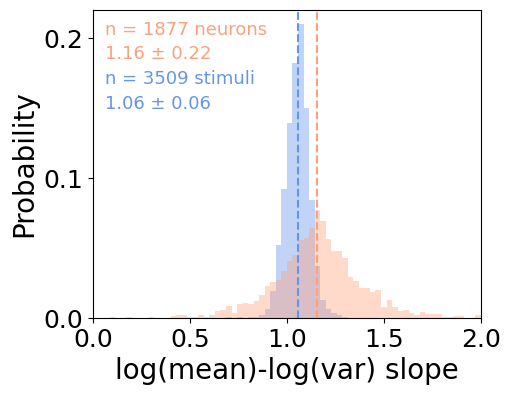

In [21]:
# loglog linear slope across trial types vs. across neurons (static gratings)

list_slopes_sg_all_att_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_sg_all_att_loglog)
                                                          if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['static_gratings']])
list_slopes_sg_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_sg_all_an_loglog)
                                                         if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['static_gratings']])

# 1. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = 0, 2
n_bins = 70

# across trial types
# weights = np.ones_like(list_slopes_sg_all_att_loglog_flattened)
weights = np.ones_like(list_slopes_sg_all_att_loglog_flattened) / len(list_slopes_sg_all_att_loglog_flattened)
ax.hist(list_slopes_sg_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_slopes_sg_all_att_loglog_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_slopes_sg_all_att_loglog_flattened):.2f}, Std {np.std(list_slopes_sg_all_att_loglog_flattened, ddof=1):.2f}')

# across neurons
# weights = np.ones_like(list_slopes_sg_all_an_loglog_flattened)
weights = np.ones_like(list_slopes_sg_all_an_loglog_flattened) / len(list_slopes_sg_all_an_loglog_flattened)
ax.hist(list_slopes_sg_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_slopes_sg_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_slopes_sg_all_an_loglog_flattened):.2f}, Std {np.std(list_slopes_sg_all_an_loglog_flattened, ddof=1):.2f}')

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

# ax.legend(loc='upper left', prop={'size': 14})
ax.set_xlim(0, 2)
# ax.annotate(f'n = {list_slopes_sg_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='lightsalmon') # w/ legend
# ax.annotate(f'n = {list_slopes_sg_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.6), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'n = {list_slopes_sg_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon') # w/o legend
# ax.annotate(f'{np.mean(list_slopes_sg_all_att_loglog_flattened):.3f} ± {sem(list_slopes_sg_all_att_loglog_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_slopes_sg_all_att_loglog_flattened):.2f} ± {np.std(list_slopes_sg_all_att_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_sg_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_sg_all_an_loglog_flattened):.3f} ± {sem(list_slopes_sg_all_an_loglog_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_sg_all_an_loglog_flattened):.2f} ± {np.std(list_slopes_sg_all_an_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')


# # plt.savefig('code_images\\svg\\sg_slope_histogram_2cond_leg.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_slope_histogram_2cond_leg.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\sg_slope_histogram_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\sg_slope_histogram_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

across trial types Mean 0.14, Std 0.20
across neurons Mean 0.14, Std 0.05


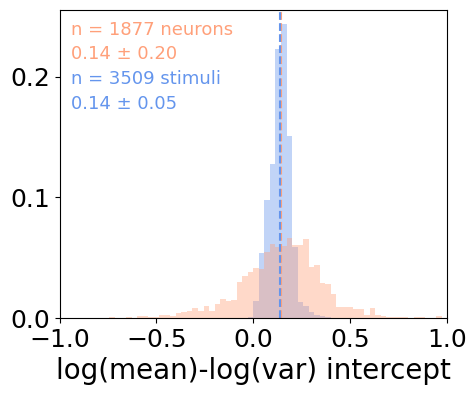

In [22]:
# loglog linear intercept across trial types vs. across neurons (static gratings)
list_intcpts_sg_all_att_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_sg_all_att_loglog)
                                                          if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['static_gratings']])
list_intcpts_sg_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_sg_all_an_loglog)
                                                         if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['static_gratings']])

# 1. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = -1, 1
n_bins = 70

# across trial types
# weights = np.ones_like(list_intcpts_sg_all_att_loglog_flattened)
weights = np.ones_like(list_intcpts_sg_all_att_loglog_flattened) / len(list_intcpts_sg_all_att_loglog_flattened)
ax.hist(list_intcpts_sg_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_intcpts_sg_all_att_loglog_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_intcpts_sg_all_att_loglog_flattened):.2f}, Std {np.std(list_intcpts_sg_all_att_loglog_flattened, ddof=1):.2f}')

# across neurons
# weights = np.ones_like(list_intcpts_sg_all_an_loglog_flattened)
weights = np.ones_like(list_intcpts_sg_all_an_loglog_flattened) / len(list_intcpts_sg_all_an_loglog_flattened)
ax.hist(list_intcpts_sg_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_intcpts_sg_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_intcpts_sg_all_an_loglog_flattened):.2f}, Std {np.std(list_intcpts_sg_all_an_loglog_flattened, ddof=1):.2f}')

ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(-1, 1.1, 0.5))
ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

# ax.legend(loc='upper left', prop={'size': 14})
ax.set_xlim(-1, 1)
ax.annotate(f'n = {list_intcpts_sg_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon') # no legend
# ax.annotate(f'{np.mean(list_intcpts_sg_all_att_loglog_flattened):.3f} ± {sem(list_intcpts_sg_all_att_loglog_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_intcpts_sg_all_att_loglog_flattened):.2f} ± {np.std(list_intcpts_sg_all_att_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_sg_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_sg_all_an_loglog_flattened):.3f} ± {sem(list_intcpts_sg_all_an_loglog_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_sg_all_an_loglog_flattened):.2f} ± {np.std(list_intcpts_sg_all_an_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\sg_intcpt_histogram_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\sg_intcpt_histogram_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1i

In [23]:
# # Linear Fitting Slope across stimuli (ABO Neuropixels drifting gratings 250ms all neurons) (loglog line)

# num_sess = len(list_sess_ids)

# # Iterate over all sessions
# list_slopes_dg75_250_all_att_loglog = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid): # 48, 49: no V1 units
#         print(f'session index: {sess_ind}')
        
#         rate = list_rate_dg75_250_all[sess_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate = rate * 0.25

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for ind, neu_ind in enumerate(rate_sorted_mean_coll.index):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, ind] = popt.copy()
        
#         list_slopes_dg75_250_all_att_loglog[sess_ind] = slopes.copy()

In [24]:
# # Linear Fitting Slope across neurons (ABO Neuropixels drifting gratings 250ms all neurons) (loglog line)

# num_sess = len(list_sess_ids)

# # Iterate over all sessions
# list_slopes_dg75_250_all_an_loglog = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid): # 48, 49: no V1 units
#         print(f'session index: {sess_ind}')
        
#         rate = list_rate_dg75_250_all[sess_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate = rate * 0.25

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_dg75_250_all_an_loglog[sess_ind] = slopes.copy()

across trial types Mean 1.15, Std 0.44
across neurons Mean 1.06, Std 0.06


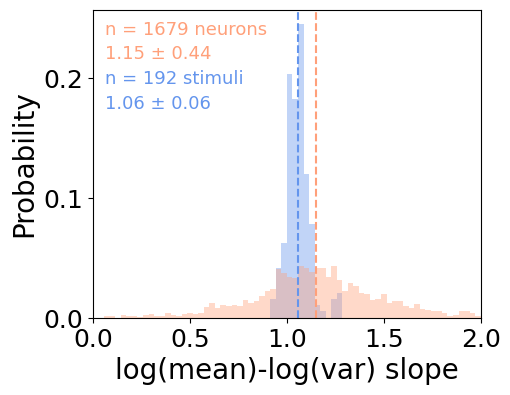

In [25]:
# loglog linear slope across trial types vs. across neurons (drifting gratings 250ms)

list_slopes_dg75_250_all_att_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_dg75_250_all_att_loglog)
                                                                if slopes is not None and sess_ind not in list_invalid_sess_visp['drifting_gratings_75_repeats']])
list_slopes_dg75_250_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_dg75_250_all_an_loglog)
                                                               if slopes is not None and sess_ind not in list_invalid_sess_visp['drifting_gratings_75_repeats']])

# 1. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = 0, 2
n_bins = 70

# across trial types
weights = np.ones_like(list_slopes_dg75_250_all_att_loglog_flattened) / len(list_slopes_dg75_250_all_att_loglog_flattened)
ax.hist(list_slopes_dg75_250_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_slopes_dg75_250_all_att_loglog_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_slopes_dg75_250_all_att_loglog_flattened):.2f}, Std {np.std(list_slopes_dg75_250_all_att_loglog_flattened, ddof=1):.2f}')

# across neurons
weights = np.ones_like(list_slopes_dg75_250_all_an_loglog_flattened) / len(list_slopes_dg75_250_all_an_loglog_flattened)
ax.hist(list_slopes_dg75_250_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_slopes_dg75_250_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_slopes_dg75_250_all_an_loglog_flattened):.2f}, Std {np.std(list_slopes_dg75_250_all_an_loglog_flattened, ddof=1):.2f}')

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

# ax.legend(loc='upper left', prop={'size': 14})
ax.set_xlim(0, 2)
# ax.annotate(f'n = {list_slopes_dg75_250_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='lightsalmon') # w/ legend
# ax.annotate(f'n = {list_slopes_dg75_250_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.6), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'n = {list_slopes_dg75_250_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon') # w/o legend
# ax.annotate(f'{np.mean(list_slopes_dg75_250_all_att_loglog_flattened):.3f} ± {sem(list_slopes_dg75_250_all_att_loglog_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_slopes_dg75_250_all_att_loglog_flattened):.2f} ± {np.std(list_slopes_dg75_250_all_att_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_dg75_250_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_slopes_dg75_250_all_an_loglog_flattened):.3f} ± {sem(list_slopes_dg75_250_all_an_loglog_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_slopes_dg75_250_all_an_loglog_flattened):.2f} ± {np.std(list_slopes_dg75_250_all_an_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# # plt.savefig('code_images\\svg\\dg75_250_slope_histogram_2cond_ylab.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_slope_histogram_2cond_ylab.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\dg75_250_slope_histogram_2cond_noleg.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\dg75_250_slope_histogram_2cond_noleg.png', dpi=300, bbox_inches='tight')
plt.show()

across trial types Mean 0.21, Std 0.31
across neurons Mean 0.16, Std 0.07


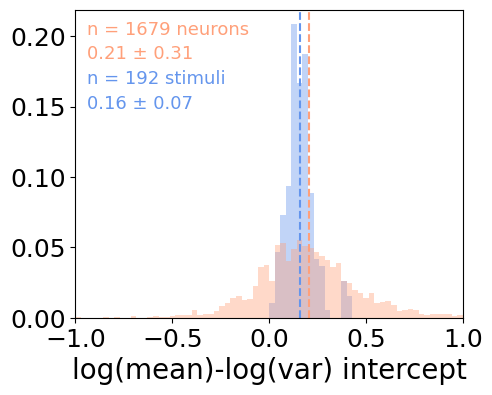

In [26]:
# loglog linear intercept across trial types vs. across neurons (drifting gratings 250ms)
list_intcpts_dg75_250_all_att_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_dg75_250_all_att_loglog)
                                                                 if slopes is not None and sess_ind not in list_invalid_sess_visp['drifting_gratings_75_repeats']])
list_intcpts_dg75_250_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_dg75_250_all_an_loglog)
                                                                if slopes is not None and sess_ind not in list_invalid_sess_visp['drifting_gratings_75_repeats']])

# 1. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
lower_bound, upper_bound = -1, 1
n_bins = 175
n_bins = 70

# across trial types
# weights = np.ones_like(list_intcpts_dg75_250_all_att_loglog_flattened)
weights = np.ones_like(list_intcpts_dg75_250_all_att_loglog_flattened) / len(list_intcpts_dg75_250_all_att_loglog_flattened)
ax.hist(list_intcpts_dg75_250_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='neurons', zorder=2)
ax.axvline(np.nanmean(list_intcpts_dg75_250_all_att_loglog_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_intcpts_dg75_250_all_att_loglog_flattened):.2f}, Std {np.std(list_intcpts_dg75_250_all_att_loglog_flattened, ddof=1):.2f}')

# across neurons
# weights = np.ones_like(list_intcpts_dg75_250_all_an_loglog_flattened)
weights = np.ones_like(list_intcpts_dg75_250_all_an_loglog_flattened) / len(list_intcpts_dg75_250_all_an_loglog_flattened)
ax.hist(list_intcpts_dg75_250_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='stimuli', zorder=1)
ax.axvline(np.nanmean(list_intcpts_dg75_250_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_intcpts_dg75_250_all_an_loglog_flattened):.2f}, Std {np.std(list_intcpts_dg75_250_all_an_loglog_flattened, ddof=1):.2f}')

ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
# ax.set_ylabel('Number', fontsize=18)
# ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(-1, 1.1, 0.5))
# ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

# ax.legend(loc='upper right', prop={'size': 14})
ax.set_xlim(-1, 1)
ax.annotate(f'n = {list_intcpts_dg75_250_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
# ax.annotate(f'{np.mean(list_intcpts_dg75_250_all_att_loglog_flattened):.3f} ± {sem(list_intcpts_dg75_250_all_att_loglog_flattened):.3f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'{np.mean(list_intcpts_dg75_250_all_att_loglog_flattened):.2f} ± {np.std(list_intcpts_dg75_250_all_att_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_dg75_250_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
# ax.annotate(f'{np.mean(list_intcpts_dg75_250_all_an_loglog_flattened):.3f} ± {sem(list_intcpts_dg75_250_all_an_loglog_flattened):.3f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
ax.annotate(f'{np.mean(list_intcpts_dg75_250_all_an_loglog_flattened):.2f} ± {np.std(list_intcpts_dg75_250_all_an_loglog_flattened, ddof=1):.2f}', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\dg75_250_intcpt_histogram_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\dg75_250_intcpt_histogram_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 2a left, 2b left

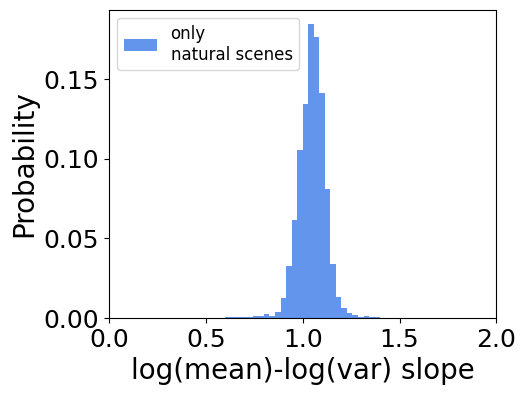

1.0507518355485015
Slope mean = 1.04823547904541, SEM = 0.0011374232625347997, std = 0.06767429453396459


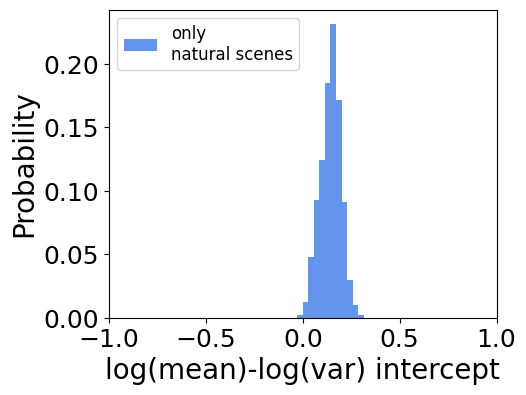

0.14737582311212133
Intercept mean = 0.14349304966911164, SEM = 0.000874723268533181, std = 0.052044196791355475


In [27]:
# Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (only natural scenes)

# # Iterate over all sessions
# list_slopes_all_an_loglog = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     print(f'session index: {sess_ind}')

#     rate = rate.sort_index(axis=1)
#     stm = rate.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate = rate * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#     # Calculate and collect linear slopes for all stimuli
#     slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#     for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#         # loglog scale
#         bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#         popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                             np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
        
#         slopes[:, trial_type_ind] = popt.copy()
    
#     list_slopes_all_an_loglog[sess_ind] = slopes.copy()

# Histogram of slopes (all sessions)

# 1. slope
fig, ax = plt.subplots(figsize=(5, 4))

list_slopes_all_an_loglog_flattened = np.concatenate([slopes[0, 1:] for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
n_bins = 70
lower_bound, upper_bound = 0, 2

weights = np.ones_like(list_slopes_all_an_loglog_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_flattened) / len(list_slopes_all_an_loglog_flattened)
ax.hist(list_slopes_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', label='only\nnatural scenes')

# ax.set_title(f'Only natural scenes', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(lower_bound, upper_bound)
ax.legend(loc='upper left', prop={'size': 12})

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_slopes_all_an_loglog_flattened, np.ones_like(list_slopes_all_an_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

# plt.savefig('code_images\\svg\\onlyns_slope_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onlyns_slope_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print(np.median(list_slopes_all_an_loglog_flattened))
print(f'Slope mean = {np.mean(list_slopes_all_an_loglog_flattened)}, SEM = {sem(list_slopes_all_an_loglog_flattened)}, std = {np.std(list_slopes_all_an_loglog_flattened, ddof=1)}')

# 2. intercept
fig, ax = plt.subplots(figsize=(5, 4))

list_intcpts_all_an_loglog_flattened = np.concatenate([slopes[1, 1:] for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
n_bins = 70
lower_bound, upper_bound = -1, 1

weights = np.ones_like(list_intcpts_all_an_loglog_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_flattened) / len(list_intcpts_all_an_loglog_flattened)
ax.hist(list_intcpts_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', label='only\nnatural scenes')

# ax.set_title(f'Only natural scenes', fontsize=20)
ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(lower_bound, upper_bound)
ax.legend(loc='upper left', prop={'size': 12})

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_intcpts_all_an_loglog_flattened, np.ones_like(list_intcpts_all_an_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

# plt.savefig('code_images\\svg\\onlyns_intcpt_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onlyns_intcpt_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print(np.median(list_intcpts_all_an_loglog_flattened))
print(f'Intercept mean = {np.mean(list_intcpts_all_an_loglog_flattened)}, SEM = {sem(list_intcpts_all_an_loglog_flattened)}, std = {np.std(list_intcpts_all_an_loglog_flattened, ddof=1)}')

## Supplementary Figure 2a right, 2b right

time window 250ms


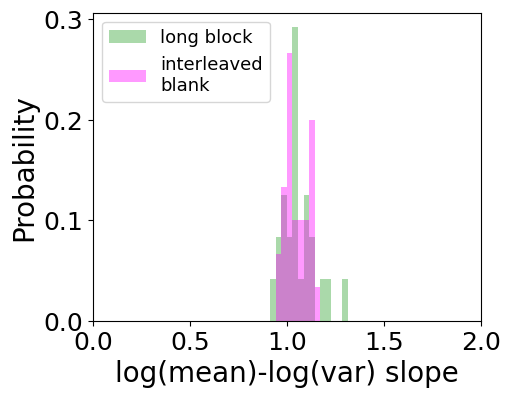

1.0385977461894649
Slope mean = 1.0606347901353208, SEM = 0.017097341066787237, std = 0.08375952314392186


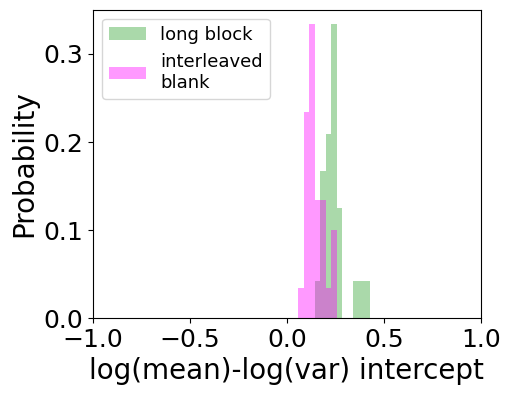

0.2343155077377339
Intercept mean = 0.24615711499144943, SEM = 0.013013597257384739, std = 0.06375334599735043


In [28]:
# Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (spontaneous in functional connectivity sessions)
list_wins_spt = [50, 100, 250, 500, 1000, 2000, 10000, 20000]
rng = np.random.default_rng(0)
num_trials_thin = 50

# Iterate over all sessions
num_sess = len(list_sess_ids)
# list_slopes_spt_diffwin_all_an_loglog = np.empty((num_sess, len(list_wins_spt)), dtype=object)
list_slopes_spt_thin_diffwin_all_an_loglog = np.empty((num_sess, len(list_wins_spt)), dtype=object) # sample 50 trials
for win_ind, win in enumerate(list_wins_spt):
    if win == 250:
        print(f'time window {win}ms')
        for sess_ind, sess_id in enumerate(list_sess_ids):
            if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid): # 48, 49: no V1 units
                # print(f'session index: {sess_ind}')
                
                rate = list_rate_spt_diffwin_all[sess_ind, win_ind].sort_index(axis=1)
                stm = rate.columns.copy()
                num_trials = rate.shape[1]

                # sample 50 trials
                rand_trial_inds = rng.choice(np.arange(num_trials), num_trials_thin, replace=False)
                rate = rate.iloc[:, rand_trial_inds]
                stm = rate.columns.copy()

                # Create a counting dictionary for each stimulus
                all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
                stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

                # Compute mean & variance for each stimulus
                rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
                rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

                # Calculate and collect linear slopes for all stimuli
                slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
                for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
                    # loglog scale
                    bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
                    popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
                                        np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
                    
                    slopes[:, trial_type_ind] = popt.copy()
                
                # list_slopes_spt_diffwin_all_an_loglog[sess_ind, win_ind] = slopes.copy()
                list_slopes_spt_thin_diffwin_all_an_loglog[sess_ind, win_ind] = slopes.copy()

        # Histogram of slopes (all sessions)

        # 1. slope
        fig, ax = plt.subplots(figsize=(5, 4))

        list_slopes_spt_diffwin_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_diffwin_all_an_loglog[:, win_ind])
                                                                        if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
        list_slopes_spt_diffwin_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                        if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
        n_bins = 70
        lower_bound, upper_bound = 0, 2

        weights = np.ones_like(list_slopes_spt_diffwin_all_an_loglog_flattened)
        weights = np.ones_like(list_slopes_spt_diffwin_all_an_loglog_flattened) / len(list_slopes_spt_diffwin_all_an_loglog_flattened)
        ax.hist(list_slopes_spt_diffwin_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='tab:green', alpha=0.4, label='long block') # #8AA624
        # ax.annotate(f'n = {list_slopes_spt_diffwin_all_an_loglog_flattened.shape[0]} sessions', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=14, color='#8AA624')
        
        # natural scenes grayscreen trials
        list_slopes_spt_all_an_loglog_flattened = np.concatenate([slopes[0, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog)
                                                                if sess_ind != 0 and sess_ind != 6])
        weights = np.ones_like(list_slopes_spt_all_an_loglog_flattened)
        weights = np.ones_like(list_slopes_spt_all_an_loglog_flattened) / len(list_slopes_spt_all_an_loglog_flattened)
        ax.hist(list_slopes_spt_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='magenta', alpha=0.4, label='interleaved\nblank') # #FEA405
        # ax.annotate(f'n = {list_slopes_spt_all_an_loglog_flattened.shape[0]} sessions', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=14, color='#FEA405')

        # ax.set_title(f'Spontaneous {win}ms', fontsize=20)
        ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
        ax.set_ylabel('Probability', fontsize=20)
        ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
        # ax.set_yticks([100, 300, 500, 700])
        ax.tick_params('both', labelsize=18)

        ax.set_xlim(lower_bound, upper_bound)
        ax.legend(loc='upper left', prop={'size': 13})

        # Wilcoxon signed-rank test
        wilc = list(wilcoxon(list_slopes_spt_diffwin_all_an_loglog_flattened, np.ones_like(list_slopes_spt_diffwin_all_an_loglog_flattened), alternative='greater'))
        # plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

        # # plt.savefig(f'code_images\\svg\\spt_slope_histogram_win{win}.svg', bbox_inches='tight')
        # # plt.savefig(f'code_images\\png\\spt_slope_histogram_win{win}.png', dpi=300, bbox_inches='tight')
        # plt.savefig(f'code_images\\svg\\spt_thin_slope_histogram_win{win}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\png\\spt_thin_slope_histogram_win{win}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(np.median(list_slopes_spt_diffwin_all_an_loglog_flattened))
        print(f'Slope mean = {np.mean(list_slopes_spt_diffwin_all_an_loglog_flattened)}, SEM = {sem(list_slopes_spt_diffwin_all_an_loglog_flattened)}, std = {np.std(list_slopes_spt_diffwin_all_an_loglog_flattened, ddof=1)}')

        # 2. intercept
        fig, ax = plt.subplots(figsize=(5, 4))

        list_intcpts_spt_diffwin_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_diffwin_all_an_loglog[:, win_ind])
                                                                        if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
        list_intcpts_spt_diffwin_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                        if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
        n_bins = 70
        lower_bound, upper_bound = -1, 1

        weights = np.ones_like(list_intcpts_spt_diffwin_all_an_loglog_flattened)
        weights = np.ones_like(list_intcpts_spt_diffwin_all_an_loglog_flattened) / len(list_intcpts_spt_diffwin_all_an_loglog_flattened)
        ax.hist(list_intcpts_spt_diffwin_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='tab:green', alpha=0.4, label='long block') # #8AA624
        # ax.annotate(f'n = {list_intcpts_spt_diffwin_all_an_loglog_flattened.shape[0]} sessions', xy=(0.03, 0.76), xycoords='axes fraction', fontsize=14, color='#8AA624')
        
        # natural scenes grayscreen trials
        list_intcpts_spt_all_an_loglog_flattened = np.concatenate([slopes[1, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog)
                                                                if sess_ind != 0 and sess_ind != 6])
        weights = np.ones_like(list_intcpts_spt_all_an_loglog_flattened)
        weights = np.ones_like(list_intcpts_spt_all_an_loglog_flattened) / len(list_intcpts_spt_all_an_loglog_flattened)
        ax.hist(list_intcpts_spt_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='magenta', alpha=0.4, label='interleaved\nblank') # #FEA405
        # ax.annotate(f'n = {list_intcpts_spt_all_an_loglog_flattened.shape[0]} sessions', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=14, color='#FEA405')

        # ax.set_title(f'Spontaneous {win}ms', fontsize=20)
        ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
        ax.set_ylabel('Probability', fontsize=20)
        ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
        # ax.set_yticks([100, 300, 500, 700])
        ax.tick_params('both', labelsize=18)

        ax.set_xlim(lower_bound, upper_bound)
        ax.legend(loc='upper left', prop={'size': 13})

        # Wilcoxon signed-rank test
        wilc = list(wilcoxon(list_intcpts_spt_diffwin_all_an_loglog_flattened, np.ones_like(list_intcpts_spt_diffwin_all_an_loglog_flattened), alternative='greater'))
        # plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

        # # plt.savefig(f'code_images\\svg\\spt_intcpt_histogram_win{win}.svg', bbox_inches='tight')
        # # plt.savefig(f'code_images\\png\\spt_intcpt_histogram_win{win}.png', dpi=300, bbox_inches='tight')
        # plt.savefig(f'code_images\\svg\\spt_thin_intcpt_histogram_win{win}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\png\\spt_thin_intcpt_histogram_win{win}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(np.median(list_intcpts_spt_diffwin_all_an_loglog_flattened))
        print(f'Intercept mean = {np.mean(list_intcpts_spt_diffwin_all_an_loglog_flattened)}, SEM = {sem(list_intcpts_spt_diffwin_all_an_loglog_flattened)}, std = {np.std(list_intcpts_spt_diffwin_all_an_loglog_flattened, ddof=1)}')

In [29]:
# 1. natural scenes vs. spontaneous (ISI) significance test

# slope
list_slopes_stim_all_an_loglog_flattened = np.concatenate([slopes[0, 1:].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_slopes_spt_all_an_loglog_flattened = np.concatenate([slopes[0, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
pval = list(mannwhitneyu(list_slopes_stim_all_an_loglog_flattened, list_slopes_spt_all_an_loglog_flattened))[1]
print(f'Natural scenes (n={len(list_slopes_stim_all_an_loglog_flattened)}) vs. spontaneous (ISI) (n={len(list_slopes_spt_all_an_loglog_flattened)})')
print(f'slope p={pval}')

# intercept
list_intcpts_stim_all_an_loglog_flattened = np.concatenate([slopes[1, 1:].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_intcpts_spt_all_an_loglog_flattened = np.concatenate([slopes[1, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
pval = list(mannwhitneyu(list_intcpts_stim_all_an_loglog_flattened, list_intcpts_spt_all_an_loglog_flattened))[1]
print(f'intercept p={pval}\n')


# 2. natural scenes vs. spontaneous (functional connectivity) significance test
win_ind = 2 # 250ms

# slope
list_slopes_stim_all_an_loglog_flattened = np.concatenate([slopes[0, 1:].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_slopes_spt_thin_diffwin_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                    if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
pval = list(mannwhitneyu(list_slopes_stim_all_an_loglog_flattened, list_slopes_spt_thin_diffwin_all_an_loglog_flattened))[1]
print(f'Natural scenes (n={len(list_slopes_stim_all_an_loglog_flattened)}) vs. spontaneous (long block) (n={len(list_slopes_spt_thin_diffwin_all_an_loglog_flattened)})')
print(f'slope p={pval}')

# intercept
list_intcpts_stim_all_an_loglog_flattened = np.concatenate([slopes[1, 1:].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_intcpts_spt_thin_diffwin_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                   if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
pval = list(mannwhitneyu(list_intcpts_stim_all_an_loglog_flattened, list_intcpts_spt_thin_diffwin_all_an_loglog_flattened))[1]
print(f'intercept p={pval}\n')


# 3. spontaneous (ISI) vs. spontaneous (functional connectivity) significance test
win_ind = 2 # 250ms

# slope
list_slopes_spt_all_an_loglog_flattened = np.concatenate([slopes[0, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_slopes_spt_thin_diffwin_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                    if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
pval = list(mannwhitneyu(list_slopes_spt_all_an_loglog_flattened, list_slopes_spt_thin_diffwin_all_an_loglog_flattened))[1]
print(f'Spontaneous (ISI) (n={len(list_slopes_spt_all_an_loglog_flattened)}) vs. spontaneous (long block) (n={len(list_slopes_spt_thin_diffwin_all_an_loglog_flattened)})')
print(f'slope p={pval}')

# intercept
list_intcpts_spt_all_an_loglog_flattened = np.concatenate([slopes[1, 0].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
list_intcpts_spt_thin_diffwin_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_thin_diffwin_all_an_loglog[:, win_ind])
                                                                   if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']])
pval = list(mannwhitneyu(list_intcpts_spt_all_an_loglog_flattened, list_intcpts_spt_thin_diffwin_all_an_loglog_flattened))[1]
print(f'intercept p={pval}')

Natural scenes (n=3540) vs. spontaneous (ISI) (n=30)
slope p=0.7371910000121293
intercept p=0.9779327347019491

Natural scenes (n=3540) vs. spontaneous (long block) (n=24)
slope p=0.9056461939084003
intercept p=7.438001481203736e-13

Spontaneous (ISI) (n=30) vs. spontaneous (long block) (n=24)
slope p=0.923724918398048
intercept p=2.45106540858035e-07


## Supplementary Figure 8a, b

In [30]:
# # Linear Fitting Slope across trial types (ABO Neuropixels all neurons) (loglog line) (different time windows, truncated) (~12 sec per window)

# num_sess = 32
# list_wins = np.arange(50, 250, 50) # time window size

# # Iterate over all sessions
# list_slopes_diffwin_trunc_all_att_loglog = np.empty((num_sess, len(list_wins)), dtype=object)
# for win_ind, win in enumerate(list_wins):
#     print(f'time window {win}ms')
#     for sess_ind in range(num_sess):
#         # print(f'session index: {sess_ind}')
        
#         rate = list_rate_diffwin_trunc_all[sess_ind, win_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for neu_ind in rate_sorted_mean_coll.index:

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, neu_ind] = popt.copy()
                
#         list_slopes_diffwin_trunc_all_att_loglog[sess_ind, win_ind] = slopes.copy()

In [31]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (different time windows, truncated) (~14 sec per window)

# num_sess = 32
# list_wins = np.arange(50, 250, 50) # time window size

# # Iterate over all sessions
# list_slopes_diffwin_trunc_all_an_loglog = np.empty((num_sess, len(list_wins)), dtype=object)
# for win_ind, win in enumerate(list_wins):
#     print(f'time window {win}ms')
#     for sess_ind in range(num_sess):
#         # print(f'session index: {sess_ind}')
        
#         rate = list_rate_diffwin_trunc_all[sess_ind, win_ind].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
                
#         list_slopes_diffwin_trunc_all_an_loglog[sess_ind, win_ind] = slopes.copy()

Across stimuli mean 0.998982317862775, std 0.1553094580588456, SEM 0.0035425926121231428
Across neurons mean 1.0052068485604773, std 0.05823724872941678, SEM 0.0009746905189460074


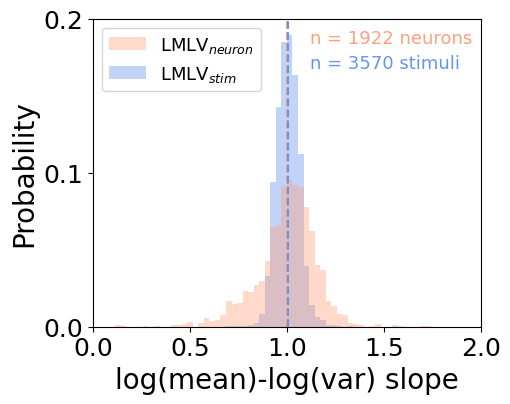

Across stimuli mean 0.9937242990368664, std 0.1939122614169568, SEM 0.004423118548488667
Across neurons mean 1.0261542757140472, std 0.0687698925189495, SEM 0.0011509706191408418


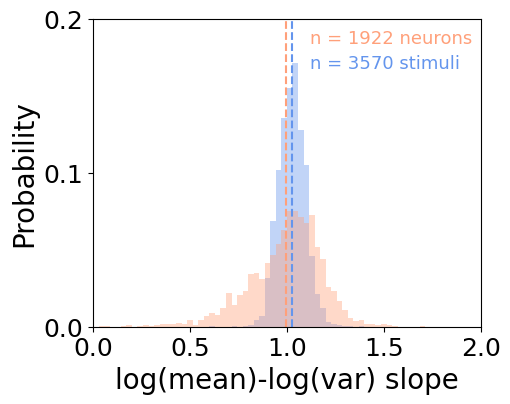

1922
3570
friedman p = 0.0 (neurons), p = 0.0 (stimuli)
[0 1 2 3 4]


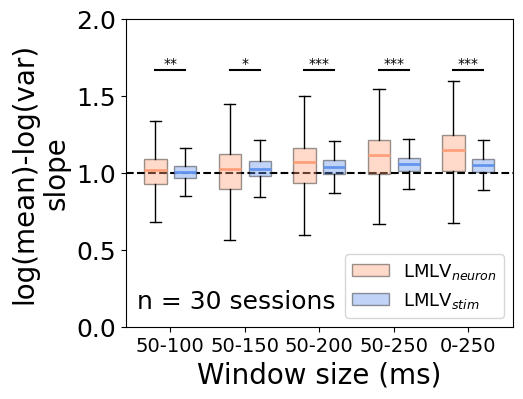

In [64]:
# loglog linear slope across trial types vs. across neurons (different time windows, truncated)
list_wins = np.arange(50, 250, 50) # time window size
num_sess = 30

# 1. histogram
for win_ind, win in enumerate(list_wins):
    if win in [50, 100]:
        list_slopes_diffwin_trunc_all_att_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_diffwin_trunc_all_att_loglog[:, win_ind]) if sess_ind != 0 and sess_ind != 6])
        list_slopes_diffwin_trunc_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_diffwin_trunc_all_an_loglog[:, win_ind]) if sess_ind != 0 and sess_ind != 6])

        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        lower_bound, upper_bound = 0, 2
        n_bins = 70

        # across trial types
        # weights = np.ones_like(list_slopes_diffwin_trunc_all_att_loglog_flattened)
        weights = np.ones_like(list_slopes_diffwin_trunc_all_att_loglog_flattened) / len(list_slopes_diffwin_trunc_all_att_loglog_flattened)
        ax.hist(list_slopes_diffwin_trunc_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
        ax.axvline(np.nanmean(list_slopes_diffwin_trunc_all_att_loglog_flattened), color='lightsalmon', linestyle='--')
        print(f'Across stimuli mean {np.nanmean(list_slopes_diffwin_trunc_all_att_loglog_flattened)}, std {np.std(list_slopes_diffwin_trunc_all_att_loglog_flattened, ddof=1)}, SEM {sem(list_slopes_diffwin_trunc_all_att_loglog_flattened, nan_policy="omit")}')

        # across neurons
        # weights = np.ones_like(list_slopes_diffwin_trunc_all_an_loglog_flattened)
        weights = np.ones_like(list_slopes_diffwin_trunc_all_an_loglog_flattened) / len(list_slopes_diffwin_trunc_all_an_loglog_flattened)
        ax.hist(list_slopes_diffwin_trunc_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
                weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
        ax.axvline(np.nanmean(list_slopes_diffwin_trunc_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')
        print(f'Across neurons mean {np.nanmean(list_slopes_diffwin_trunc_all_an_loglog_flattened)}, std {np.std(list_slopes_diffwin_trunc_all_an_loglog_flattened, ddof=1)}, SEM {sem(list_slopes_diffwin_trunc_all_an_loglog_flattened, nan_policy="omit")}')

        # ax.set_title(f'{win}ms', fontsize=20)
        ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
        # if win == 50:
        if True:
            ax.set_ylabel('Number', fontsize=18)
            ax.set_ylabel('Probability', fontsize=20)
        ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.set_yticks(np.arange(0, 0.21, 0.1))
        ax.tick_params('both', labelsize=18)

        if win == 50:
            ax.legend(loc='upper left', prop={'size': 13})
        ax.annotate(f'n = {list_slopes_diffwin_trunc_all_att_loglog_flattened.shape[0]} neurons', xy=(0.56, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
        ax.annotate(f'n = {list_slopes_diffwin_trunc_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.56, 0.84), xycoords='axes fraction', fontsize=13, color='cornflowerblue')
        ax.set_xlim(0, 2)
        ax.set_ylim(0, 0.2)

        # plt.savefig(f'code_images\\svg\\diffwin_slope_histogram_win{win}.svg', bbox_inches='tight')
        # plt.savefig(f'code_images\\png\\diffwin_slope_histogram_win{win}.png', dpi=300, bbox_inches='tight')
        plt.show()

# 2. box plot
list_wins_orig = np.concatenate([list_wins, [250]])
list_slopes_att_intv = np.empty(len(list_wins_orig), dtype=object)
list_slopes_an_intv = np.empty(len(list_wins_orig), dtype=object)
for win_ind, win in enumerate(list_wins):
    list_slopes_att_intv[win_ind] = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_diffwin_trunc_all_att_loglog[:, win_ind]) if sess_ind != 0 and sess_ind != 6])
    # print(len(list_slopes_att_intv[win_ind]))
    # print(np.sum(np.isnan(list_slopes_att_intv[win_ind])))
    list_slopes_an_intv[win_ind] = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_diffwin_trunc_all_an_loglog[:, win_ind]) if sess_ind != 0 and sess_ind != 6])
    # print(len(list_slopes_an_intv[win_ind]))
    # print(np.sum(np.isnan(list_slopes_an_intv[win_ind])))
list_slopes_att_intv[-1] = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog) if sess_ind != 0 and sess_ind != 6])
list_slopes_an_intv[-1] = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog) if sess_ind != 0 and sess_ind != 6])
print(len(list_slopes_att_intv[-1]))
print(len(list_slopes_an_intv[-1]))

n_box = len(list_wins_orig)
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = list_wins_orig.copy()
xticklabels = ['50-100', '50-150', '50-200', '50-250', '0-250']
d_x_att = -0.1
d_x_an = 0.1

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
box = axes[0].boxplot(list_slopes_att_intv, positions=center+d_x_att,
                      showfliers=False, patch_artist=True, widths=0.15, label='LMLV$_{neuron}$', zorder=1)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='lightsalmon', alpha=0.4) # box color
    median_.set(color='lightsalmon', linewidth=2) # median line color
box = axes[0].boxplot(list_slopes_an_intv, positions=center+d_x_an,
                      showfliers=False, patch_artist=True, widths=0.15, label='LMLV$_{stim}$', zorder=1)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='cornflowerblue', alpha=0.4) # box color
    median_.set(color='cornflowerblue', linewidth=2) # median line color

axes[0].axhline(1, color='k', linestyle='--', zorder=0)

pval_fried_att = list(friedmanchisquare(*list_slopes_att_intv))[1]
pval_fried_an = list(friedmanchisquare(*list_slopes_an_intv))[1]
print(f'friedman p = {pval_fried_att} (neurons), p = {pval_fried_an} (stimuli)')

list_pvals_slope = np.zeros(n_box)
for win_ind, win in enumerate(list_wins_orig):
    list_pvals_slope[win_ind] = list(mannwhitneyu(list_slopes_att_intv[win_ind], list_slopes_an_intv[win_ind]))[1]
list_pvals_slope = np.array(multipletests(list_pvals_slope, method='holm')[1]) # multiple comparisons correction
print(np.where(list_pvals_slope < 0.05)[0])
center_annot = np.stack([center+d_x_att, center+d_x_an], axis=0).T.flatten()
n_box_annot = n_box*2
whiskers = [get_upper_whisker(d) for d in np.concatenate([list_slopes_att_intv, list_slopes_an_intv])]
add_significance_bars(ax=axes[0], comparisons=np.arange(n_box_annot).reshape(5, 2), y_max_values=[np.max(whiskers)*1.03]*n_box_annot, x_positions=center_annot,
                    p_values=list_pvals_slope, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(0, 2.1, 0.5))
axes[0].legend(loc='lower right', prop={'size': 13})

axes[0].set_xlabel('Window size (ms)', fontsize=20)
axes[0].set_ylabel('log(mean)-log(var)\nslope', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=14)

axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\diffwin_slope_boxplot.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\diffwin_slope_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 8c

friedman p = 2.577145630750063e-19


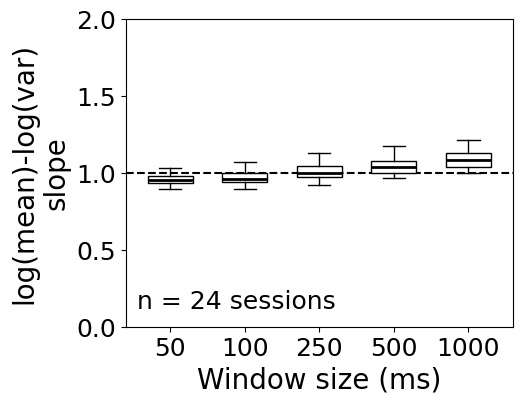

In [33]:
list_wins_spt = [50, 100, 250, 500, 1000, 2000, 10000, 20000]
list_wins_spt = [50, 100, 250, 500, 1000]

# box plot
list_slopes_spt_an_intv = np.empty(len(list_wins_spt), dtype=object)
for win_ind, win in enumerate(list_wins_spt):
    list_slopes_spt_an_intv[win_ind] = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_spt_diffwin_all_an_loglog[:, win_ind]) if slopes is not None])

n_box = len(list_wins_spt)
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = list_wins_spt.copy()
d_x = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
box = axes[0].boxplot(list_slopes_spt_an_intv, positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color
axes[0].axhline(1, color='k', linestyle='--', zorder=0)

pval_fried_spt = list(friedmanchisquare(*list_slopes_spt_an_intv))[1]
print(f'friedman p = {pval_fried_spt}')

axes[0].set_xlabel('Window size (ms)', fontsize=20)
axes[0].set_ylabel('log(mean)-log(var)\nslope', fontsize=20)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=14)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(0, 2.1, 0.5))

num_sess = len([True for sess_ind, slopes in enumerate(list_slopes_spt_diffwin_all_an_loglog[:, 0]) if slopes is not None and sess_ind not in list_invalid_sess_visp['spontaneous']]) # 모든 win_ind에 대해 동일함을 확인함.
axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\spt_diffwin_slope_boxplot.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\spt_diffwin_slope_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 8d

In [34]:
# # Collect effective dimensionality for each session (different time windows)
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100
# list_wins = np.arange(50, 250, 50) # time window size

# list_dim_asis2 = np.zeros((num_sess, len(list_wins), num_trial_types))
# list_dim_RRneuron3 = np.zeros((num_sess, len(list_wins), len(list_target_slopes), num_trial_types))
# list_dim_global_asis2 = np.zeros((num_sess, len(list_wins), 2))
# list_dim_global_RRneuron3 = np.zeros((num_sess, len(list_wins), len(list_target_slopes), 2))
# list_dim_sam_asis2 = np.zeros((num_sess, len(list_wins), n_trial_sampling))
# list_dim_sam_RRneuron3 = np.zeros((num_sess, len(list_wins), len(list_target_slopes), n_trial_sampling))
# for sess_ind in range(num_sess):
#     file_name = 'eff_dim_DC_diffwin_trunc_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         eff_dim_DC_ABO = pickle.load(f)
#         list_dim_asis2[sess_ind] = eff_dim_DC_ABO['list_dim_asis2'].copy()
#         list_dim_RRneuron3[sess_ind] = eff_dim_DC_ABO['list_dim_RRneuron2'].copy()
#         list_dim_global_asis2[sess_ind] = eff_dim_DC_ABO['list_dim_global_asis2'].copy()
#         list_dim_global_RRneuron3[sess_ind] = eff_dim_DC_ABO['list_dim_global_RRneuron2'].copy()
#         list_dim_sam_asis2[sess_ind] = eff_dim_DC_ABO['list_dim_sam_asis2'].copy()
#         list_dim_sam_RRneuron3[sess_ind] = eff_dim_DC_ABO['list_dim_sam_RRneuron2'].copy()

# save_file_name = 'eff_dim_DC_diffwin_trunc2.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis2', 'list_dim_RRneuron3', 'list_dim_global_asis2', 'list_dim_global_RRneuron3', 'list_dim_sam_asis2', 'list_dim_sam_RRneuron3'],
#                 'list_dim_asis2': list_dim_asis2, 'list_dim_RRneuron3': list_dim_RRneuron3, 'list_dim_global_asis2': list_dim_global_asis2, 'list_dim_global_RRneuron3': list_dim_global_RRneuron3,
#                 'list_dim_sam_asis2': list_dim_sam_asis2, 'list_dim_sam_RRneuron3': list_dim_sam_RRneuron3}, f)

time window 50ms
time window 100ms


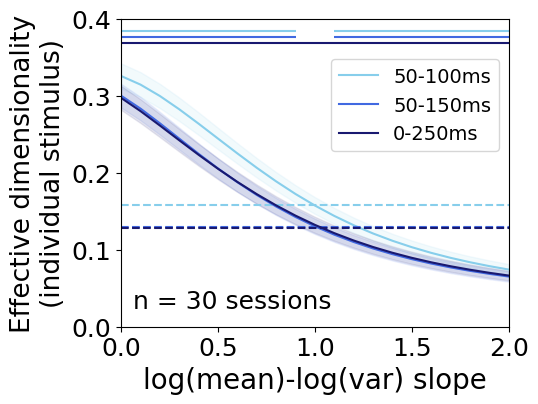

In [65]:
# Effective dimensionality (different time windows)

save_filename = 'eff_dim_DC_diffwin_trunc2.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), use spike count, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_diffwin_trunc = pickle.load(f)

    list_dim_asis2 = eff_dim_diffwin_trunc['list_dim_asis2'].copy()
    list_dim_RRneuron3 = eff_dim_diffwin_trunc['list_dim_RRneuron3'].copy()
    list_dim_global_asis2 = eff_dim_diffwin_trunc['list_dim_global_asis2'].copy()
    list_dim_global_RRneuron3 = eff_dim_diffwin_trunc['list_dim_global_RRneuron3'].copy()
    list_dim_sam_asis2 = eff_dim_diffwin_trunc['list_dim_sam_asis2'].copy()
    list_dim_sam_RRneuron3 = eff_dim_diffwin_trunc['list_dim_sam_RRneuron3'].copy()
num_sess = list_dim_asis2.shape[0]
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = [~np.any(np.isin(sess_ind, [0, 6])) for sess_ind in range(num_sess)]

list_dim_asis2 = list_dim_asis2[bool_sess]
list_dim_RRneuron3 = list_dim_RRneuron3[bool_sess]
list_dim_global_asis2 = list_dim_global_asis2[bool_sess]
list_dim_global_RRneuron3 = list_dim_global_RRneuron3[bool_sess]
list_dim_sam_asis2 = list_dim_sam_asis2[bool_sess]
list_dim_sam_RRneuron3 = list_dim_sam_RRneuron3[bool_sess]

list_wins = np.arange(50, 250, 50) # time window size

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
d_x_diff = 0.1
list_d_x = [-d_x_diff, 0, d_x_diff]
list_colors = ['tab:blue', 'tab:orange', 'tab:green']
list_colors = ['skyblue', 'royalblue', 'midnightblue']
for win_ind, win in enumerate(list_wins[:2]): # only for 50, 100 ms
    print(f'time window {win}ms')
    
    list_dim_asis = list_dim_asis2[:, win_ind].copy()
    list_dim_RRneuron2 = list_dim_RRneuron3[:, win_ind].copy()
    list_dim_global_asis = list_dim_global_asis2[:, win_ind].copy()
    list_dim_global_RRneuron2 = list_dim_global_RRneuron3[:, win_ind].copy()
    list_dim_sam_asis = list_dim_sam_asis2[:, win_ind].copy()
    list_dim_sam_RRneuron2 = list_dim_sam_RRneuron3[:, win_ind].copy()

    # fig, axes = plt.subplots(1, 1, figsize=(5, 4))
    # axes = np.array(axes).flatten()
    color = list_colors[win_ind]

    # line plot
    list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
    list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

    axes[0].plot(list_target_slopes, list_means_dim, color=color, label=f'50-{50+win}ms')
    axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color=color, alpha=0.1)

    # as-is average
    axes[0].axhline(np.nanmean(list_dim_asis), color=color, linestyle='--')

    # significance
    axes[0].set_ylim(0, 0.4) # line plot
    list_pvals_dim_diffwin_trunc = np.zeros(len(list_target_slopes))
    for slope_ind, target_slope in enumerate(list_target_slopes):
        list_pvals_dim_diffwin_trunc[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                        np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
    list_pvals_dim_diffwin_trunc = np.array(multipletests(list_pvals_dim_diffwin_trunc, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_dim = list_target_slopes[list_pvals_dim_diffwin_trunc < 0.05].copy()    
    annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96-0.02*win_ind, color=color)

    axes[0].set_xlim(0, 2)
    # height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
    # axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

    # axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
    # if win == 50:
    #     axes[0].set_ylabel('Effective dimensionality', fontsize=19)
    # axes[0].tick_params('both', labelsize=18)

    # axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
    
    # # plt.savefig(f'code_images\\svg\\diffwin_effdim_win{win}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\diffwin_effdim_win{win}.png', dpi=300, bbox_inches='tight')
    # plt.show()

# 250 ms
save_filename = 'eff_dim_DC_ABO3.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()
color = list_colors[2]

# line plot
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color=color, label=f'0-250ms')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color=color, alpha=0.1)

# as-is average
axes[0].axhline(np.nanmean(list_dim_asis), color=color, linestyle='--')

# significance
axes[0].set_ylim(0, 0.4)
list_pvals_dim_ABO = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                  np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_ABO = np.array(multipletests(list_pvals_dim_ABO, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_ABO < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=None, ax_ind=None, line_height_ratio=0.92, color=color)

axes[0].set_xlim(0, 2)
# height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.9), prop={'size': 14})

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\diffwin_effdim_win250.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\diffwin_effdim_win250.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\diffwin_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\diffwin_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 8e

In [37]:
# # Collect decoding for each session (SVM) (different time windows)

# decoder_type = 'SVM'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# list_wins = np.arange(50, 250, 50) # time window size

# list_mean_confusion_test2 = np.full((num_sess, len(list_wins), num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy2 = np.full((num_sess, len(list_wins)), np.nan)
# list_mean_confusion_test_RRneuron3 = np.full((len(list_wins), len(list_target_slopes), num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy_RRneuron3 = np.full((len(list_wins), len(list_target_slopes), num_sess), np.nan)
# for sess_ind in range(num_sess):
#     file_name = decoder_type + '_decoding_diffwin_trunc_allstim_' + str(sess_ind) + '.pickle'

#     with open(file_name, 'rb') as f:
#         decoding_ABO = pickle.load(f)

#         list_mean_confusion_test2[sess_ind] = decoding_ABO['list_mean_confusion_test_asis'].copy()
#         list_mean_accuracy2[sess_ind] = decoding_ABO['list_mean_accuracy_asis']
#         list_mean_confusion_test_RRneuron3[:, :, sess_ind] = decoding_ABO['list_mean_confusion_test_RRneuron2'].copy()
#         list_mean_accuracy_RRneuron3[:, :, sess_ind] = decoding_ABO['list_mean_accuracy_RRneuron2'].copy()

# save_file_name = decoder_type + '_decoding_diffwin_trunc_allstim_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test2', 'list_mean_accuracy2', 'list_mean_confusion_test_RRneuron3', 'list_mean_accuracy_RRneuron3'],
#                     'list_mean_confusion_test2': list_mean_confusion_test2, 'list_mean_accuracy2': list_mean_accuracy2,
#                     'list_mean_confusion_test_RRneuron3': list_mean_confusion_test_RRneuron3, 'list_mean_accuracy_RRneuron3': list_mean_accuracy_RRneuron3}, f)

time window 50ms
time window 100ms


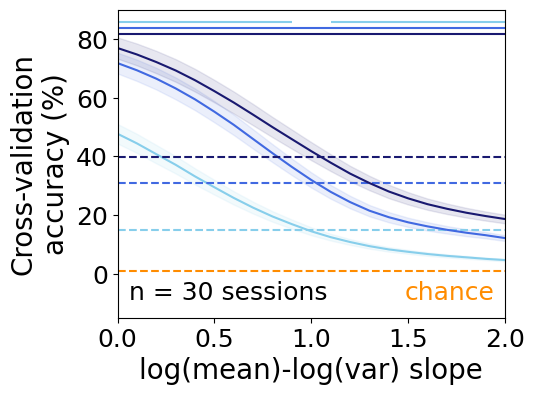

In [39]:
# decoding plot across slopes (ABO, SVM) (different time windows)

decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_diffwin_trunc_allstim_all.pickle' # SVM max_iter=1000, use spike count
save_file_name = decoder_type + '_decoding_diffwin_trunc_allstim_all2.pickle' # same as above, use 3d matrix
with open(save_file_name, 'rb') as f:
    decoding_all = pickle.load(f)

    # list_mean_confusion_test2 = dc(decoding_all['list_mean_confusion_test2'])
    list_mean_accuracy2 = dc(decoding_all['list_mean_accuracy2'])
    # list_mean_confusion_test_RRneuron3 = dc(decoding_all['list_mean_confusion_test_RRneuron3'])
    list_mean_accuracy_RRneuron3 = dc(decoding_all['list_mean_accuracy_RRneuron3'])
list_mean_accuracy2 = 100 * list_mean_accuracy2
list_mean_accuracy_RRneuron3 = 100 * list_mean_accuracy_RRneuron3

num_sess = list_mean_accuracy2.shape[0]
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_trial_types = 119

# exclude session 0, 6
bool_sess = [~np.any(np.isin(sess_ind, [0, 6])) for sess_ind in range(num_sess)]
list_mean_accuracy2 = list_mean_accuracy2[bool_sess]
list_mean_accuracy_RRneuron3 = list_mean_accuracy_RRneuron3[:, :, bool_sess]

list_wins = np.arange(50, 250, 50) # time window size

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
d_x_diff = 0.1
list_d_x = [-d_x_diff, 0, d_x_diff]
list_colors = ['tab:blue', 'tab:orange', 'tab:green']
list_colors = ['skyblue', 'royalblue', 'midnightblue']
for win_ind, win in enumerate(list_wins[:2]): # only for 50, 100 ms
    print(f'time window {win}ms')

    list_mean_accuracy = list_mean_accuracy2[:, win_ind]
    list_mean_accuracy_RRneuron2 = list_mean_accuracy_RRneuron3[win_ind]

    # test accuracy

    # fig, axes = plt.subplots(1, 1, figsize=(5, 4))
    # axes = np.array(axes).flatten()
    color = list_colors[win_ind]

    # line plot
    x = list_target_slopes.copy()
    list_means_accuracy = np.array([np.mean(list_mean_accuracy_RRneuron2[slope_ind]) \
                           for slope_ind in range(len(list_target_slopes))])
    list_errs_accuracy = np.array([sem(list_mean_accuracy_RRneuron2[slope_ind]) \
                          for slope_ind in range(len(list_target_slopes))])

    axes[0].plot(x, list_means_accuracy, color=color)
    axes[0].fill_between(x, list_means_accuracy-list_errs_accuracy, \
                         list_means_accuracy+list_errs_accuracy, color=color, alpha=0.1)

    # as-is
    axes[0].axhline(np.mean(list_mean_accuracy), c=color, linestyle='--')

    # significance
    axes[0].set_ylim(-15, 90)
    list_pvals_RRneuron2 = np.zeros(len(list_target_slopes)) # test accuracy
    for slope_ind, slope in enumerate(list_target_slopes):
        list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
    list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction
    annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96-0.02*win_ind, color=color)

    axes[0].set_xlim(0, 2)
    # height = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
    # axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

    # axes[0].set_title('Cross-validation Accuracy', fontsize=17)
    axes[0].set_xlabel('Rescale factor of r', fontsize=20)
    axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if win == 50:
        axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
    axes[0].tick_params('both', labelsize=18)

    # axes[0].axhline(100*1/num_trial_types, c='darkorange', linestyle='--') # chance level
    # axes[0].annotate(f'n = {list_mean_accuracy.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
    # axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')

    # # plt.savefig(f'code_images\\svg\\diffwin_decoding_win{win}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\diffwin_decoding_win{win}.png', dpi=300, bbox_inches='tight')
    # plt.show()

# 250 ms
save_file_name = decoder_type + '_decoding_ABO_allstim_all.pickle' # randomness matched (slope 0~2), logit/SVM max_iter=1000/-1
# save_file_name = decoder_type + '_decoding_ABO_allstim_all2.pickle' # randomness matched (slope 0~2), logit/SVM max_iter=100
save_file_name = decoder_type + '_decoding_ABO_allstim_all3.pickle' # randomness matched (slope 0~2), SVM max_iter=1000
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)

    # list_mean_confusion_test = dc(decoding_ABO_all['list_mean_confusion_test'])
    list_mean_accuracy = dc(decoding_ABO_all['list_mean_accuracy'])
    # list_mean_confusion_test_RRneuron2 = dc(decoding_ABO_all['list_mean_confusion_test_RRneuron2'])
    list_mean_accuracy_RRneuron2 = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'])

# exclude session 0, 6
list_mean_accuracy = np.array(list_mean_accuracy)
list_mean_accuracy_RRneuron2 = np.stack(list_mean_accuracy_RRneuron2)
list_mean_accuracy = np.concatenate([list_mean_accuracy[1:6], list_mean_accuracy[7:]], axis=0)
list_mean_accuracy_RRneuron2 = np.concatenate([list_mean_accuracy_RRneuron2[:, 1:6], list_mean_accuracy_RRneuron2[:, 7:]], axis=1)

list_mean_accuracy = 100 * list_mean_accuracy
list_mean_accuracy_RRneuron2 = 100 * list_mean_accuracy_RRneuron2

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()
color = list_colors[2]

# line plot
list_means_accuracy = np.array([np.mean(list_mean_accuracy_RRneuron2[slope_ind]) \
                       for slope_ind in range(len(list_target_slopes))])
list_errs_accuracy = np.array([sem(list_mean_accuracy_RRneuron2[slope_ind]) \
                      for slope_ind in range(len(list_target_slopes))])

axes[0].plot(list_target_slopes, list_means_accuracy, color=color)
axes[0].fill_between(list_target_slopes, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color=color, alpha=0.1)

# as-is average
axes[0].axhline(np.mean(list_mean_accuracy), c=color, linestyle='--')

# significance
axes[0].set_ylim(-15, 90)
list_pvals_RRneuron2 = np.zeros(len(list_target_slopes)) # test accuracy
for slope_ind, slope in enumerate(list_target_slopes):
    list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction
annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.92, color=color)

axes[0].set_xlim(0, 2)
# height = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_mean_accuracy.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].axhline(100*1/num_trial_types, c='darkorange', linestyle='--') # chance level
axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')

# # plt.savefig('code_images\\svg\\diffwin_decoding_win250.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\diffwin_decoding_win250.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\diffwin_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\diffwin_decoding.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 8f

In [40]:
# # Collect correlation for each session (within session) (different time windows)
# similarity_type = 'cos_sim'
# # similarity_type = 'geodesic'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_neu_sampling = 10
# list_wins = np.arange(50, 250, 50) # time window size

# list_corr_withinsess_asis3 = np.zeros((num_sess, len(list_wins), n_neu_sampling, 3))
# list_corr_withinsess4 = np.zeros((num_sess, len(list_wins), len(list_target_slopes), n_neu_sampling, 3))
# list_RSM_neu1_all3 = np.full((num_sess, len(list_wins), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_all3 = np.full((num_sess, len(list_wins), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu1_RRneuron_all3 = np.full((num_sess, len(list_wins), len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_RRneuron_all3 = np.full((num_sess, len(list_wins), len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_corr_withinsess_diffwin_trunc_' + similarity_type + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_corr_withinsess = pickle.load(f)

#         list_corr_withinsess_asis3[sess_ind] = RSM_corr_withinsess['list_corr_withinsess_asis2'].copy()
#         list_corr_withinsess4[sess_ind] = RSM_corr_withinsess['list_corr_withinsess3'].copy()
#         list_RSM_neu1_all3[sess_ind] = RSM_corr_withinsess['list_RSM_neu1_all2'].copy()
#         list_RSM_neu2_all3[sess_ind] = RSM_corr_withinsess['list_RSM_neu2_all2'].copy()
#         list_RSM_neu1_RRneuron_all3[sess_ind] = RSM_corr_withinsess['list_RSM_neu1_RRneuron_all2'].copy()
#         list_RSM_neu2_RRneuron_all3[sess_ind] = RSM_corr_withinsess['list_RSM_neu2_RRneuron_all2'].copy()

# save_file_name = 'RSM_corr_withinsess_diffwin_trunc_all_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_corr_withinsess_asis3', 'list_corr_withinsess4', 'list_RSM_neu1_all3', 'list_RSM_neu2_all3', 'list_RSM_neu1_RRneuron_all3', 'list_RSM_neu2_RRneuron_all3'], \
#                 'list_corr_withinsess_asis3': list_corr_withinsess_asis3, 'list_corr_withinsess4': list_corr_withinsess4, 'list_RSM_neu1_all3': list_RSM_neu1_all3, 'list_RSM_neu2_all3': list_RSM_neu2_all3,
#                 'list_RSM_neu1_RRneuron_all3': list_RSM_neu1_RRneuron_all3, 'list_RSM_neu2_RRneuron_all3': list_RSM_neu2_RRneuron_all3}, f)

time window 50ms
time window 100ms


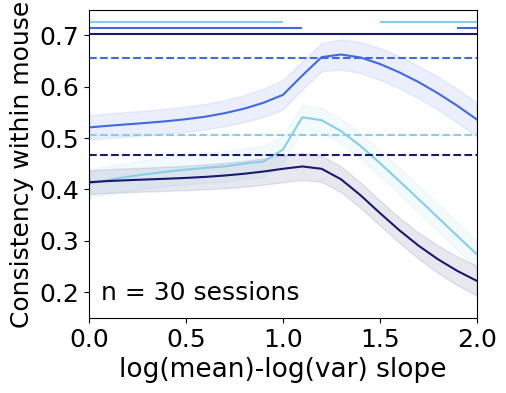

In [42]:
# RSA within session (different time windows)

similarity_type = 'cos_sim'

save_file_name = 'RSM_corr_withinsess_diffwin_trunc_all_' + similarity_type + '.pickle' # include as-is, trial combination, RSM within sessions, use spike count
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_gratings_all = pickle.load(f)
    list_corr_withinsess_asis3 = RSM_corr_withinsess_gratings_all['list_corr_withinsess_asis3'].copy()
    list_corr_withinsess4 = RSM_corr_withinsess_gratings_all['list_corr_withinsess4'].copy()

num_sess = list_corr_withinsess_asis3.shape[0]
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = [~np.any(np.isin(sess_ind, [0, 6])) for sess_ind in range(num_sess)]
list_corr_withinsess_asis3 = list_corr_withinsess_asis3[bool_sess]
list_corr_withinsess4 = list_corr_withinsess4[bool_sess]

corr_ind = 0
list_wins = np.arange(50, 250, 50) # time window size

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
d_x_diff = 0.1
list_d_x = [-d_x_diff, 0, d_x_diff]
list_colors = ['skyblue', 'royalblue', 'midnightblue']
for win_ind, win in enumerate(list_wins[:2]): # only for 50, 100 ms
    print(f'time window {win}ms')

    list_corr_withinsess_asis2 = list_corr_withinsess_asis3[:, win_ind]
    list_corr_withinsess3 = list_corr_withinsess4[:, win_ind]

    # fig, axes = plt.subplots(1, 1, figsize=(5, 4))
    # axes = np.array(axes).flatten()
    color = list_colors[win_ind]

    # line plot
    x = list_target_slopes.copy()
    list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(0, 2))
    list_errs_corr_withinsess = sem(np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=0, nan_policy='omit')

    axes[0].plot(x, list_means_corr_withinsess, color=color)
    axes[0].fill_between(x, list_means_corr_withinsess-list_errs_corr_withinsess, \
                         list_means_corr_withinsess+list_errs_corr_withinsess, color=color, alpha=0.1)

    # as-is
    axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c=color, linestyle='--', label='as-is')

    # Wilcoxon signed-rank test (across session pairs)
    axes[0].set_ylim(0.15, 0.75)
    list_pvals_corr_withinsess_gratings = np.full((3, len(list_target_slopes)), np.nan)
    for corr_ind in range(3):
        pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[:, slope_ind, :, corr_ind].mean(axis=1)))[1]\
                      for slope_ind in range(len(list_target_slopes))]
        pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
        list_pvals_corr_withinsess_gratings[corr_ind] = pvals_temp.copy()
    corr_ind = 0
    list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess_gratings[corr_ind] < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96-0.02*win_ind, color=color)

    axes[0].set_xlim(0, 2)
    # height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
    # if win == 50:
    #     axes[0].annotate('as-is', xy=(0.03, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
    # elif win == 100:
    #     axes[0].annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

    # axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
    # if win == 50:
    #     axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
    #     axes[0].set_ylabel('Similarity within mouse', fontsize=19)
    # axes[0].tick_params('both', labelsize=18)

    # axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\diffwin_RSA_within_win{win}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\diffwin_RSA_within_win{win}.png', dpi=300, bbox_inches='tight')
    # plt.show()

# 250 ms
save_file_name = 'RSM_corr_withinsess_ABO_all3_' + similarity_type + '.pickle' # slope 0~2, including as-is, trial combination, neuron partioning matched
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask_06].copy()
list_corr_withinsess3 = list_corr_withinsess3[:, mask_06].copy()

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()
color = list_colors[2]

# line plot
list_means_corr_withinsess = np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=(1, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=1)

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color=color)
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color=color, alpha=0.1)

# as-is
axes[0].axhline(np.mean(list_corr_withinsess_asis2[:, :, corr_ind]), c=color, linestyle='--', label='as-is')

# significance
axes[0].set_ylim(0.15, 0.75)
list_pvals_corr_withinsess_ABO = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[slope_ind, :, :, corr_ind].mean(axis=1)))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess_ABO[corr_ind] = pvals_temp.copy()

corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess_ABO[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.92, color=color)

axes[0].set_xlim(0, 2)
# height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\diffwin_RSA_within_win250.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\diffwin_RSA_within_win250.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\diffwin_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\diffwin_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 8g

In [43]:
# # Collect RSM for each session (across session pairs) (different time windows)
# similarity_type = 'geodesic'
# similarity_type = 'cos_sim'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# list_wins = np.arange(50, 250, 50) # time window size

# list_RSM_mean_asis2 = np.full((num_sess, len(list_wins), num_trial_types, num_trial_types), np.nan)
# list_RSM_mean_RRneuron3 = np.full((num_sess, len(list_wins), len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_rate_RRneuron_dr3 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_diffwin_trunc_allneu_' + similarity_type + str(sess_ind) + '.pickle'

#     with open(file_name, 'rb') as f:
#         RSM = pickle.load(f)
#         list_RSM_mean_asis2[sess_ind] = RSM['list_RSM_mean_asis2'].copy()
#         list_RSM_mean_RRneuron3[sess_ind] = RSM['list_RSM_mean_RRneuron2'].copy()
#         list_rate_RRneuron_dr3[sess_ind] = RSM['list_rate_RRneuron_dr2'].copy()

# # # Exclude sessions of low quality
# # bool_sess = [~np.any(np.isin(sess_ind, [0, 6])) for sess_ind in range(num_sess)]
# # list_RSM_mean_asis2 = list_RSM_mean_asis2[bool_sess]
# # list_RSM_mean_RRneuron3 = list_RSM_mean_RRneuron3[bool_sess]

# # Spearman correlation across session pairs
# num_sess = 32
# sess_pairs = list(combinations(range(num_sess), 2))
# list_corr_sesspair_asis2 = np.zeros((len(sess_pairs), len(list_wins), 3))
# list_corr_sesspair3 = np.zeros((len(sess_pairs), len(list_wins), len(list_target_slopes), 3))
# for win_ind, win in enumerate(list_wins[:2]): # only for 50, 100 ms
#     print(f'time window {win}ms')
    
#     for pair_ind, pair in enumerate(sess_pairs):
#         RSM_mean_neu1 = list_RSM_mean_asis2[pair[0], win_ind].copy()
#         RSM_mean_neu2 = list_RSM_mean_asis2[pair[1], win_ind].copy()

#         list_corr_sesspair_asis2[pair_ind, win_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#         bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#         list_corr_sesspair_asis2[pair_ind, win_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#         list_corr_sesspair_asis2[pair_ind, win_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())
        
#         for slope_ind, target_slope in enumerate(list_target_slopes):
#             RSM_mean_neu1 = list_RSM_mean_RRneuron3[pair[0], win_ind, slope_ind].copy()
#             RSM_mean_neu2 = list_RSM_mean_RRneuron3[pair[1], win_ind, slope_ind].copy()

#             list_corr_sesspair3[pair_ind, win_ind, slope_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#             bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#             list_corr_sesspair3[pair_ind, win_ind, slope_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#             list_corr_sesspair3[pair_ind, win_ind, slope_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())

# save_file_name = 'RSM_diffwin_trunc_all_allneu_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis2', 'list_corr_sesspair_asis2', 'list_rate_RRneuron_dr3', 'list_RSM_mean_RRneuron3', 'list_corr_sesspair3'], \
#                  'list_RSM_mean_asis2': list_RSM_mean_asis2, 'list_corr_sesspair_asis2': list_corr_sesspair_asis2,
#                  'list_rate_RRneuron_dr3': list_rate_RRneuron_dr3, 'list_RSM_mean_RRneuron3': list_RSM_mean_RRneuron3, 'list_corr_sesspair3': list_corr_sesspair3}, f)

time window 50ms
time window 100ms


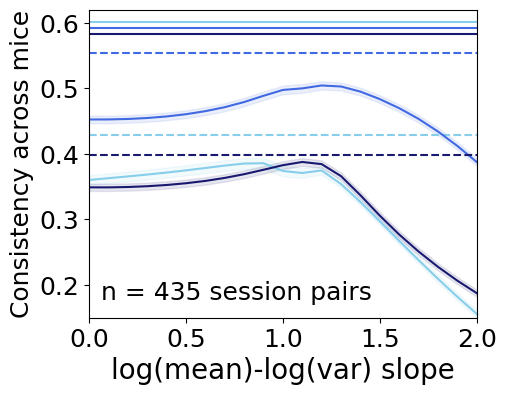

In [45]:
# RSA across sessions (different time windows)
similarity_type = 'cos_sim'

save_file_name = 'RSM_diffwin_trunc_all_allneu_' + similarity_type + '.pickle' # trial order matched, use spike count, exclude session 0, 6
with open(save_file_name, 'rb') as f:
    RSM_all = pickle.load(f)
    list_corr_sesspair_asis2 = RSM_all['list_corr_sesspair_asis2'].copy()
    list_corr_sesspair3 = RSM_all['list_corr_sesspair3'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
num_sess = 32
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_06 = ~np.any(np.isin(sess_pairs, [0, 6]), axis=1)
list_corr_sesspair_asis2 = list_corr_sesspair_asis2[mask_06].copy()
list_corr_sesspair3 = list_corr_sesspair3[mask_06].copy()

corr_ind = 0
list_wins = np.arange(50, 250, 50) # time window size

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()
d_x_diff = 0.1
list_d_x = [-d_x_diff, 0, d_x_diff]
list_colors = ['skyblue', 'royalblue', 'midnightblue']
for win_ind, win in enumerate(list_wins[:2]): # only for 50, 100 ms
    print(f'time window {win}ms')

    list_corr_sesspair_asis = list_corr_sesspair_asis2[:, win_ind]
    list_corr_sesspair2 = list_corr_sesspair3[:, win_ind]

    # fig, axes = plt.subplots(1, 1, figsize=(5, 4))
    # axes = np.array(axes).flatten()
    color = list_colors[win_ind]

    # line plot
    list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=0)
    list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=0, ddof=1, nan_policy='omit')

    axes[0].plot(list_target_slopes, list_means_corr_sesspair, color=color, label='original')
    axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                         list_means_corr_sesspair+list_errs_corr_sesspair, color=color, alpha=0.1)
    # as-is
    axes[0].axhline(np.nanmean(list_corr_sesspair_asis[:, corr_ind]), c=color, linestyle='--')

    # Wilcoxon signed-rank test (across session pairs)
    axes[0].set_ylim(0.15, 0.62)
    list_pvals_corr_sesspair = np.full((3, len(list_target_slopes)), np.nan)
    for corr_ind in range(3):
        pvals_temp = [list(wilcoxon(list_corr_sesspair_asis[:, corr_ind], list_corr_sesspair2[:, slope_ind, corr_ind]))[1]\
                      for slope_ind in range(len(list_target_slopes))]
        pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
        list_pvals_corr_sesspair[corr_ind] = pvals_temp.copy()
    corr_ind = 0
    list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair[corr_ind] < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96-0.02*win_ind, color=color)

    axes[0].set_xlim(0, 2)
    # height = (np.nanmean(list_corr_sesspair_asis[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
    # axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

    # axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
    # if win == 50:
    #     axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
    #     axes[0].set_ylabel('Similarity across mice', fontsize=20)
    # axes[0].tick_params('both', labelsize=18)

    # axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\diffwin_RSA_across_win{win}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\diffwin_RSA_across_win{win}.png', dpi=300, bbox_inches='tight')
    # plt.show()

# 250 ms
save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_' + similarity_type + '.pickle' # trial order matched (slope 0~2)
with open(save_file_name, 'rb') as f:
    RSM_corr_sesspair_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO = RSM_corr_sesspair_ABO_all['list_corr_sesspair_asis_ABO'].copy()
    list_corr_sesspair2 = RSM_corr_sesspair_ABO_all['list_corr_sesspair2'].copy()

# exclude session 0, 6
num_sess = 32
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_06 = ~np.any(np.isin(sess_pairs, [0, 6]), axis=1)
list_corr_sesspair_asis_ABO = list_corr_sesspair_asis_ABO[mask_06].copy()
list_corr_sesspair2 = list_corr_sesspair2[:, mask_06].copy()

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()
color = list_colors[2]

# line plot
list_means_corr_sesspair = np.mean(list_corr_sesspair2[:, :, corr_ind], axis=1)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=1)

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color=color, label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color=color, alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind]), c=color, linestyle='--')

# significance
axes[0].set_ylim(0.15, 0.62)
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.92, color=color)

axes[0].set_xlim(0, 2)
# height = (np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[1]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\diffwin_RSA_across_win250.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\diffwin_RSA_across_win250.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\diffwin_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\diffwin_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14a

In [46]:
# # Collect effective dimensionality for each session (drifting gratings)
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = len(list_sess_ids)
# num_trial_types = 8
# n_trial_sampling = 100

# list_dim_asis = np.zeros((num_sess, num_trial_types))
# list_dim_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), num_trial_types))
# list_dim_global_asis = np.zeros((num_sess, 2))
# list_dim_global_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), 2))
# list_dim_sam_asis = np.zeros((num_sess, n_trial_sampling))
# list_dim_sam_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), n_trial_sampling))
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid):
#         file_name = 'eff_dim_DC_dg75_250_' + str(sess_ind) + '.pickle'
        
#         with open(file_name, 'rb') as f:
#             eff_dim_DC_gratings = pickle.load(f)
#             list_dim_asis[sess_ind] = eff_dim_DC_gratings['list_dim_asis'].copy()
#             list_dim_RRneuron2[sess_ind] = eff_dim_DC_gratings['list_dim_RRneuron'].copy()
#             list_dim_global_asis[sess_ind] = eff_dim_DC_gratings['list_dim_global_asis'].copy()
#             list_dim_global_RRneuron2[sess_ind] = eff_dim_DC_gratings['list_dim_global_RRneuron'].copy()
#             list_dim_sam_asis[sess_ind] = eff_dim_DC_gratings['list_dim_sam_asis'].copy()
#             list_dim_sam_RRneuron2[sess_ind] = eff_dim_DC_gratings['list_dim_sam_RRneuron'].copy()

# save_file_name = 'eff_dim_DC_dg75_250_all5.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis', 'list_dim_RRneuron2', 'list_dim_global_asis', 'list_dim_global_RRneuron2', 'list_dim_sam_asis', 'list_dim_sam_RRneuron2'],
#                 'list_dim_asis': list_dim_asis, 'list_dim_RRneuron2': list_dim_RRneuron2, 'list_dim_global_asis': list_dim_global_asis, 'list_dim_global_RRneuron2': list_dim_global_RRneuron2,
#                 'list_dim_sam_asis': list_dim_sam_asis, 'list_dim_sam_RRneuron2': list_dim_sam_RRneuron2}, f)

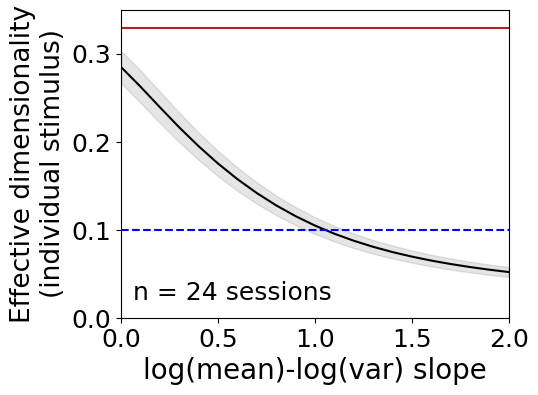

In [66]:
# Effective dimensionality (individual stimulus)

# gratings
save_filename = 'eff_dim_DC_dg75_250_all5.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), use spike count, include session 42, spike count constant modified, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_gratings = pickle.load(f)

    list_dim_asis = eff_dim_gratings['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_gratings['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_gratings['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_gratings['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_gratings['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_gratings['list_dim_sam_RRneuron2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='drifting gratings')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='b', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.35) # individual
list_pvals_dim_gratings = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_gratings[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                    np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_gratings = np.array(multipletests(list_pvals_dim_gratings, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_gratings < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.94, color='firebrick')
# height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Effective dimensionality', fontsize=19)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper right', prop={'size': 12})
# axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.93), prop={'size': 14})
axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\dg75_250_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_dg75_250_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_dg75_250_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_dg75_250_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_dg75_250_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_sg_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_sg_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14b

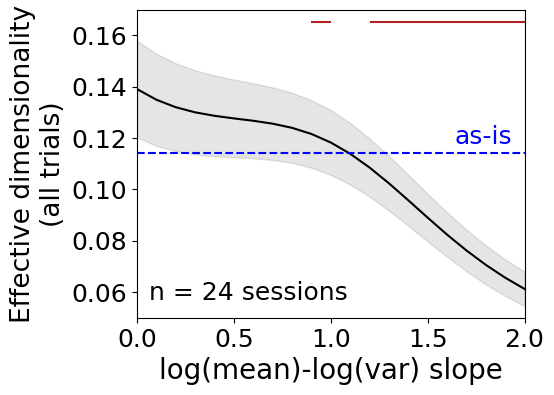

In [67]:
# Effective dimensionality (global)

# gratings
save_filename = 'eff_dim_DC_dg75_250_all5.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), use spike count, include session 42, spike count constant modified, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_gratings = pickle.load(f)

    list_dim_asis = eff_dim_gratings['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_gratings['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_gratings['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_gratings['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_gratings['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_gratings['list_dim_sam_RRneuron2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot

# global manifold
list_colors_glo = ['k', 'b']
glo_ind = 0
list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='drifting gratings')
axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color='b', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0.05, 0.17) # global
for glo_ind in [0, 1]:
    if glo_ind == 0:
        list_pvals_dim_glo_ABO = np.zeros(len(list_target_slopes))
        for slope_ind, target_slope in enumerate(list_target_slopes):
            list_pvals_dim_glo_ABO[slope_ind] = list(wilcoxon(list_dim_global_asis[:, glo_ind], list_dim_global_RRneuron2[:, slope_ind, glo_ind], nan_policy='omit'))[1]
        list_pvals_dim_glo_ABO = np.array(multipletests(list_pvals_dim_glo_ABO, method='holm')[1]) # multiple comparisons correction
        list_sig_slopes_dim_glo = list_target_slopes[list_pvals_dim_glo_ABO < 0.05].copy()
        annotate_lineplot_significance(list_sig_slopes_dim_glo, axes=None, ax_ind=None, line_height_ratio=0.96, color='firebrick')
glo_ind = 0
height = (np.nanmean(list_dim_global_asis[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is all trials', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color=list_colors_glo[glo_ind])
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Effective dimensionality', fontsize=19)
axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper right', prop={'size': 12})
# axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.93), prop={'size': 14})
axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\dg75_250_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_dg75_250_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_dg75_250_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_dg75_250_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_dg75_250_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\ns_sg_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\ns_sg_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14c

In [50]:
# # Collect decoding for each session (SVM) (drifting gratings)

# decoder_type = 'SVM'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = len(list_sess_ids)
# num_trial_types = 8

# list_mean_confusion_test = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy = np.full(num_sess, np.nan)
# list_mean_confusion_test_RRneuron2 = np.full((len(list_target_slopes), num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy_RRneuron2 = np.full((len(list_target_slopes), num_sess), np.nan)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid):
#         file_name = decoder_type + '_decoding_dg75_250_allstim_' + str(sess_ind) + '.pickle'

#         with open(file_name, 'rb') as f:
#             decoding_ABO = pickle.load(f)

#             list_mean_confusion_test[sess_ind] = decoding_ABO['mean_confusion_test_asis'].copy()
#             list_mean_accuracy[sess_ind] = decoding_ABO['mean_accuracy_asis']
#             list_mean_confusion_test_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_confusion_test_RRneuron'].copy()
#             list_mean_accuracy_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_accuracy_RRneuron'].copy()

# save_file_name = decoder_type + '_decoding_dg75_250_allstim_all4.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy', 'list_mean_confusion_test_RRneuron2', 'list_mean_accuracy_RRneuron2'],
#                     'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy,
#                     'list_mean_confusion_test_RRneuron2': list_mean_confusion_test_RRneuron2, 'list_mean_accuracy_RRneuron2': list_mean_accuracy_RRneuron2}, f)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


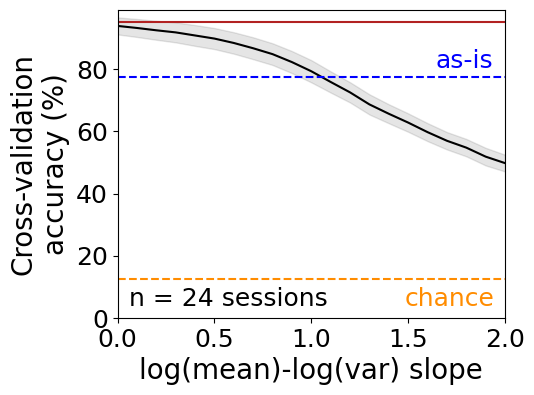

In [52]:
# decoding plot across slopes (ABO, SVM)

decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_dg75_250_allstim_all4.pickle' # SVM max_iter=1000, use spike count, include session 42, spike count constant modified
with open(save_file_name, 'rb') as f:
    decoding_all = pickle.load(f)

    list_mean_confusion_test = dc(decoding_all['list_mean_confusion_test'])
    list_mean_accuracy = dc(decoding_all['list_mean_accuracy'])
    # list_mean_confusion_test_RRneuron2 = dc(decoding_all['list_mean_confusion_test_RRneuron2'])
    list_mean_accuracy_RRneuron2 = dc(decoding_all['list_mean_accuracy_RRneuron2'])
list_mean_accuracy = 100 * list_mean_accuracy
list_mean_accuracy_RRneuron2 = 100 * list_mean_accuracy_RRneuron2

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_trial_types = list_mean_confusion_test.shape[-1]

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
list_mean_accuracy = list_mean_accuracy[bool_sess]
list_mean_accuracy_RRneuron2 = list_mean_accuracy_RRneuron2[:, bool_sess]

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_accuracy = np.array([np.mean(list_mean_accuracy_RRneuron2[slope_ind]) \
                       for slope_ind in range(len(list_target_slopes))])
list_errs_accuracy = np.array([sem(list_mean_accuracy_RRneuron2[slope_ind]) \
                      for slope_ind in range(len(list_target_slopes))])

axes[0].plot(list_target_slopes, list_means_accuracy, color='k')
axes[0].fill_between(list_target_slopes, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.mean(list_mean_accuracy), c='b', linestyle='--')

# significance
axes[0].set_ylim(0, axes[0].get_ylim()[1])
list_pvals_RRneuron2 = np.zeros(len(list_target_slopes)) # test accuracy
for slope_ind, slope in enumerate(list_target_slopes):
    # As-is vs. RRneuron Wilcoxon signed rank test
    list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction
annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

# axes[0].set_title('Cross-validation Accuracy', fontsize=17)
axes[0].set_xlabel('Rescale factor of r', fontsize=20)
axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)

axes[0].axhline(100*1/num_trial_types, c='darkorange', linestyle='--') # chance level
# axes[0].annotate(f'n = {list_mean_accuracy.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')
axes[0].annotate(f'n = {list_mean_accuracy.shape[0]} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')
axes[0].annotate(f'chance', xy=(0.74, 0.04), xycoords='axes fraction', fontsize=18, color='darkorange')

# plt.savefig('code_images\\svg\\dg75_250_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\dg75_250_decoding.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\sg_decoding.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_decoding.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\sg_decoding_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\sg_decoding_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14d

In [53]:
# # Collect correlation for each session (within session) (drifting gratings)
# similarity_type = 'cos_sim'
# # similarity_type = 'geodesic'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = len(list_sess_ids)
# num_trial_types = 8
# n_neu_sampling = 10

# list_corr_withinsess_asis2 = np.zeros((num_sess, n_neu_sampling, 3))
# list_corr_withinsess3 = np.zeros((num_sess, len(list_target_slopes), n_neu_sampling, 3))
# list_RSM_neu1_all2 = np.full((num_sess, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_all2 = np.full((num_sess, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu1_RRneuron_all2 = np.full((num_sess, len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_RRneuron_all2 = np.full((num_sess, len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid):
#         file_name = 'RSM_corr_withinsess_dg75_250_' + similarity_type + str(sess_ind) + '.pickle'
        
#         with open(file_name, 'rb') as f:
#             RSM_corr_withinsess = pickle.load(f)

#             list_corr_withinsess_asis2[sess_ind] = RSM_corr_withinsess['list_corr_withinsess_asis'].copy()
#             list_corr_withinsess3[sess_ind] = RSM_corr_withinsess['list_corr_withinsess2'].copy()
#             list_RSM_neu1_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu1_all'].copy()
#             list_RSM_neu2_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu2_all'].copy()
#             list_RSM_neu1_RRneuron_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu1_RRneuron_all'].copy()
#             list_RSM_neu2_RRneuron_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu2_RRneuron_all'].copy()

# save_file_name = 'RSM_corr_withinsess_dg75_250_all7_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_corr_withinsess_asis2', 'list_corr_withinsess3'], \
#     #              'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_corr_withinsess3': list_corr_withinsess3}, f)
#     pickle.dump({'tree_variables': ['list_corr_withinsess_asis2', 'list_corr_withinsess3', 'list_RSM_neu1_all2', 'list_RSM_neu2_all2', 'list_RSM_neu1_RRneuron_all2', 'list_RSM_neu2_RRneuron_all2'], \
#                 'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_corr_withinsess3': list_corr_withinsess3, 'list_RSM_neu1_all2': list_RSM_neu1_all2, 'list_RSM_neu2_all2': list_RSM_neu2_all2,
#                 'list_RSM_neu1_RRneuron_all2': list_RSM_neu1_RRneuron_all2, 'list_RSM_neu2_RRneuron_all2': list_RSM_neu2_RRneuron_all2}, f)

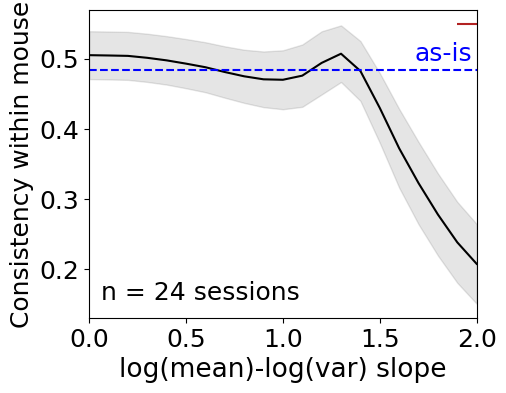

In [55]:
# RSA within session (with diagonal)

similarity_type = 'cos_sim'

save_file_name = 'RSM_corr_withinsess_dg75_250_all5_' + similarity_type + '.pickle' # include as-is, trial combination, RSM within sessions, use spike count, include session 42, spike count constant modified
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_all['list_corr_withinsess3'].copy()
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[bool_sess]
list_corr_withinsess3 = list_corr_withinsess3[bool_sess]

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(0, 2))
list_errs_corr_withinsess = sem(np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=0, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_withinsess = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[:, slope_ind, :, corr_ind].mean(axis=1), nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.84, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\dg75_250_RSA_within_nodiag.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\dg75_250_RSA_within_nodiag.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\sg_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_within_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_within_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14e

In [56]:
# # Collect RSM for each session (across session pairs) (drifting gratings)
# similarity_type = 'geodesic'
# similarity_type = 'cos_sim'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = len(list_sess_ids)
# num_trial_types = 8
# # list_RSM_mean_asis = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# # list_RSM_mean_RRneuron2 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# # list_rate_RRneuron_dr2 = np.empty(num_sess, dtype=object)
# # for sess_ind, sess_id in enumerate(list_sess_ids):
# #     if ~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid):
# #         file_name = 'RSM_dg75_250_allneu_' + similarity_type + str(sess_ind) + '.pickle'
# #         file_name = 'RSM_dg75_250_allneu_centered_' + similarity_type + str(sess_ind) + '.pickle'
# #         file_name = 'RSM_dgct_250_allneu_' + similarity_type + str(sess_ind) + '.pickle'

# #         with open(file_name, 'rb') as f:
# #             RSM = pickle.load(f)
# #             list_RSM_mean_asis[sess_ind] = RSM['list_RSM_mean_asis'].copy()
# #             list_RSM_mean_RRneuron2[sess_ind] = RSM['list_RSM_mean_RRneuron'].copy()
# #             list_rate_RRneuron_dr2[sess_ind] = RSM['list_rate_RRneuron_dr'].copy()

# save_file_name = 'RSM_dg75_250_all_allneu5_' + similarity_type + '.pickle' # trial order matched, use spike count, all sessions, remove gratings in variable names, spike count constant modified
# with open(save_file_name, 'rb') as f:
#     RSM_all = pickle.load(f)
#     list_RSM_mean_asis = RSM_all['list_RSM_mean_asis'].copy()
#     list_RSM_mean_RRneuron2 = RSM_all['list_RSM_mean_RRneuron2'].copy()

# # # only functional connectivity sessions (drifting gratings 75)
# # bool_sess = [~np.any(np.isin(sess_ind, [48, 49])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
# # list_RSM_mean_asis = list_RSM_mean_asis[bool_sess]
# # list_RSM_mean_RRneuron2 = list_RSM_mean_RRneuron2[bool_sess]

# # Spearman correlation across session pairs
# num_sess = len(list_sess_ids)
# sess_pairs = list(combinations(range(num_sess), 2))
# list_corr_sesspair_asis = np.zeros((len(sess_pairs), 3))
# list_corr_sesspair2 = np.zeros((len(sess_pairs), len(list_target_slopes), 3))
# for pair_ind, pair in enumerate(sess_pairs):
#     RSM_mean_neu1 = list_RSM_mean_asis[pair[0]].copy()
#     RSM_mean_neu2 = list_RSM_mean_asis[pair[1]].copy()

#     # exclude diagonal
#     RSM_mean_neu1[np.diag_indices(num_trial_types)] = np.nan
#     RSM_mean_neu2[np.diag_indices(num_trial_types)] = np.nan

#     list_corr_sesspair_asis[pair_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#     bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#     list_corr_sesspair_asis[pair_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#     list_corr_sesspair_asis[pair_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())
    
#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         RSM_mean_neu1 = list_RSM_mean_RRneuron2[pair[0], slope_ind].copy()
#         RSM_mean_neu2 = list_RSM_mean_RRneuron2[pair[1], slope_ind].copy()

#         # exclude diagonal
#         RSM_mean_neu1[np.diag_indices(num_trial_types)] = np.nan
#         RSM_mean_neu2[np.diag_indices(num_trial_types)] = np.nan

#         list_corr_sesspair2[pair_ind, slope_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#         bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#         list_corr_sesspair2[pair_ind, slope_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#         list_corr_sesspair2[pair_ind, slope_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())

# save_file_name = 'RSM_dg75_250_all_allneu7_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis', 'list_corr_sesspair_asis', 'list_rate_RRneuron_dr2', 'list_RSM_mean_RRneuron2', 'list_corr_sesspair2'], \
#                  'list_RSM_mean_asis': list_RSM_mean_asis, 'list_corr_sesspair_asis': list_corr_sesspair_asis,
#                  'list_rate_RRneuron_dr2': list_rate_RRneuron_dr2, 'list_RSM_mean_RRneuron2': list_RSM_mean_RRneuron2, 'list_corr_sesspair2': list_corr_sesspair2}, f)

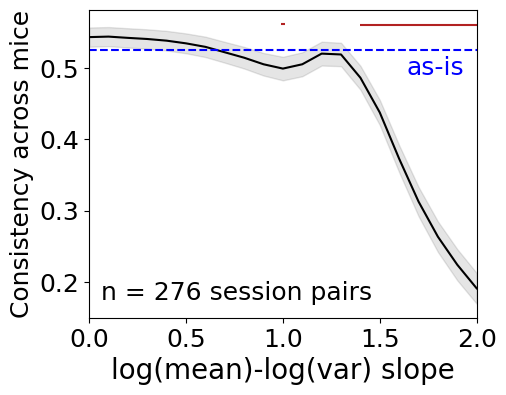

In [58]:
# RSA across sessions (with diagonal)
similarity_type = 'cos_sim'

save_file_name = 'RSM_dg75_250_all_allneu5_' + similarity_type + '.pickle' # trial order matched, use spike count, all sessions, remove gratings in variable names, spike count constant modified
with open(save_file_name, 'rb') as f:
    RSM_all = pickle.load(f)
    list_corr_sesspair_asis = RSM_all['list_corr_sesspair_asis'].copy()
    list_corr_sesspair2 = RSM_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
num_sess = int((1 + np.sqrt(1 + 8*list_corr_sesspair_asis.shape[0])) / 2) # solution of nC2 = shape[0]
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_sess = np.all(np.isin(sess_pairs, np.where(bool_sess)[0]), axis=1)
list_corr_sesspair_asis = list_corr_sesspair_asis[mask_sess]
list_corr_sesspair2 = list_corr_sesspair2[mask_sess]

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=0)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=0, ddof=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis[:, corr_ind]), c='b', linestyle='--')

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis[:, corr_ind], list_corr_sesspair2[:, slope_ind, corr_ind]))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\dg75_250_RSA_across_nodiag.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_across_nodiag.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\sg_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_across_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_across_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14f

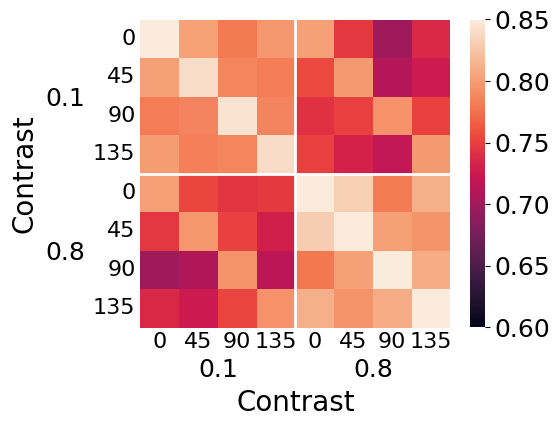

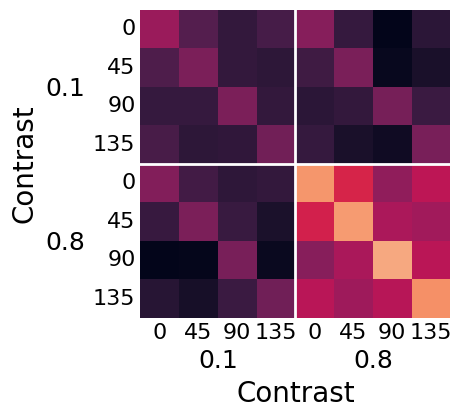

In [59]:
# RSM heatmap

similarity_type = 'cos_sim'

save_file_name = 'RSM_dg75_250_all_allneu5_' + similarity_type + '.pickle' # trial order matched, use spike count, all sessions, remove gratings in variable names, spike count constant modified
with open(save_file_name, 'rb') as f:
    RSM_all = pickle.load(f)
    list_corr_sesspair_asis = RSM_all['list_corr_sesspair_asis'].copy()
    list_RSM_mean_asis = RSM_all['list_RSM_mean_asis'].copy()
    list_RSM_mean_RRneuron2 = RSM_all['list_RSM_mean_RRneuron2'].copy()
num_sess = int((1 + np.sqrt(1 + 8*list_corr_sesspair_asis.shape[0])) / 2) # solution of nC2 = shape[0]
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
num_sess = int((1 + np.sqrt(1 + 8*list_corr_sesspair_asis.shape[0])) / 2) # solution of nC2 = shape[0]
list_RSM_mean_asis = list_RSM_mean_asis[bool_sess]
list_RSM_mean_RRneuron2 = list_RSM_mean_RRneuron2[bool_sess]

list_vminmax =[(0.6, 0.8), (0.65, 0.85)]
list_vminmax =[(0.6, 0.8), (0.75, 0.95)] # dg75
list_vminmax =[(0.55, 0.8), (0.55, 0.8)] # dg75 (paper)
list_vminmax =[(0.6, 0.85), (0.6, 0.85)] # dg75 (paper, average across sessions)
# list_vminmax =[(0.6, 0.8), (0.6, 0.8)] # dg75 (paper, average across sessions)
# reorder stimuli based on contrast, not orientation
n_ori = 4
n_ct = 2
perm = []
for c in range(n_ct):
    for d in range(n_ori):
        perm.append(d * n_ct + c)
perm = np.array(perm)
group_labels = np.unique(list_dg75_ct[27])
for ind, sess_ind in enumerate([3]): # session 3 is for paper
    # heatmap
    # sess_ind = 0
    slope_ind = 0
    cbar = True
    figsize = (5, 4) if cbar else (4, 4)
    vmin, vmax= list_vminmax[ind]

    RSM1_temp = list_RSM_mean_RRneuron2[sess_ind, slope_ind]
    RSM1_temp = np.nanmean(list_RSM_mean_RRneuron2[:, slope_ind], axis=0) # average across sessions
    RSM1_temp = RSM1_temp[np.ix_(perm, perm)]
    if cbar:
        fig, ax_hm, ax_cb = heatmap_cbar(RSM1_temp,
                                         vmin=vmin, vmax=vmax,
                                        # figsize_hm=(8, 8), figsize_all=(9, 8)
                                        )
        ax_cb.tick_params(labelsize=18)
    else:
        fig, ax_hm = plt.subplots(1, 1, figsize=figsize)
        ax_hm = sns.heatmap(RSM1_temp,
                            vmin=vmin, vmax=vmax,
                            cbar=cbar)
    # ax_hm.set_title(f'Session {sess_ind}, slope {list_target_slopes[slope_ind]:.1f}', fontsize=20)
    # ax_hm.xaxis.tick_top()

    # tick_positions = np.arange(n_ori/2, n_ori*n_ct, n_ori) # center of each group
    # ax_hm.set_xticks(tick_positions)
    # ax_hm.set_xticklabels(group_labels, fontsize=18, rotation=0)
    # ax_hm.set_yticks(tick_positions)
    # ax_hm.set_yticklabels(group_labels, fontsize=18)
    # ax_hm.set_xlabel('Contrast', fontsize=20)
    # ax_hm.set_ylabel('Contrast', fontsize=20)
    # ax_hm.tick_params(left=False, top=False, bottom=False)

    # nested labels
    directions = ['0°', '45°', '90°', '135°']
    directions = ['0', '45', '90', '135']
    ax_hm.set_xticks(np.arange(8) + 0.5, minor=False)
    ax_hm.set_xticklabels(directions * 2, rotation=0, size=16)
    ax_hm.set_yticks(np.arange(8) + 0.5, minor=False)
    ax_hm.set_yticklabels(directions * 2, rotation=0, size=16)

    ax_hm.set_xticks([2, 6], minor=True)
    ax_hm.set_xticklabels(['0.1', '0.8'], minor=True, size=18)
    # ax_hm.tick_params(axis='x', which='minor', length=0, pad=40)
    ax_hm.tick_params(axis='x', which='minor', length=0, pad=22)

    ax_hm.set_yticks([2, 6], minor=True)
    ax_hm.set_yticklabels(['0.1', '0.8'], minor=True, size=18)
    # ax_hm.tick_params(axis='y', which='minor', length=0, pad=45)
    ax_hm.tick_params(axis='y', which='minor', length=0, pad=40)

    ax_hm.tick_params(axis='both', which='major', length=0)
    ax_hm.set_xlabel('Contrast', fontsize=20, labelpad=5)
    ax_hm.set_ylabel('Contrast', fontsize=20, labelpad=5)

    # add lines to separate the groups
    for pos in np.arange(n_ori, n_ori*n_ct, n_ori):
        ax_hm.axhline(y=pos, color='white', linewidth=2)
        ax_hm.axvline(x=pos, color='white', linewidth=2)

    # # # plt.savefig(f'code_images\\svg\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.png', dpi=300, bbox_inches='tight')
    # # plt.savefig(f'code_images\\svg\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.svg', bbox_inches='tight')
    # plt.savefig(f'code_images\\png\\dg75_250_RSM_across_sessmean_slope{list_target_slopes[slope_ind]:.0f}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # sess_ind = 1
    slope_ind = 10
    cbar = False
    figsize = (5, 4) if cbar else (4, 4)
    vmin, vmax= list_vminmax[ind]

    RSM1_temp = list_RSM_mean_RRneuron2[sess_ind, slope_ind]
    RSM1_temp = np.nanmean(list_RSM_mean_RRneuron2[:, slope_ind], axis=0) # average across sessions
    RSM1_temp = np.nanmean(list_RSM_mean_asis, axis=0) # average across sessions
    RSM1_temp = RSM1_temp[np.ix_(perm, perm)]
    if cbar:
        fig, ax_hm, ax_cb = heatmap_cbar(RSM1_temp,
                                         vmin=vmin, vmax=vmax,
                                        # figsize_hm=(8, 8), figsize_all=(9, 8)
                                        )
        ax_cb.tick_params(labelsize=18)
    else:
        fig, ax_hm = plt.subplots(1, 1, figsize=figsize)
        ax_hm = sns.heatmap(RSM1_temp,
                            vmin=vmin, vmax=vmax,
                            cbar=cbar)
    # ax_hm.set_title(f'Session {sess_ind}, slope {list_target_slopes[slope_ind]:.1f}', fontsize=20)
    # ax_hm.xaxis.tick_top()

    # tick_positions = np.arange(n_ori/2, n_ori*n_ct, n_ori) # center of each group
    # ax_hm.set_xticks(tick_positions)
    # ax_hm.set_xticklabels(group_labels, fontsize=18, rotation=0)
    # ax_hm.set_yticks(tick_positions)
    # ax_hm.set_yticklabels(group_labels, fontsize=18)
    # ax_hm.set_xlabel('Contrast', fontsize=20)
    # ax_hm.set_ylabel('Contrast', fontsize=20)
    # ax_hm.tick_params(left=False, top=False, bottom=False)

    # nested labels
    # directions = ['0°', '45°', '90°', '135°']
    ax_hm.set_xticks(np.arange(8) + 0.5, minor=False)
    ax_hm.set_xticklabels(directions * 2, rotation=0, size=16)
    ax_hm.set_yticks(np.arange(8) + 0.5, minor=False)
    ax_hm.set_yticklabels(directions * 2, rotation=0, size=16)

    ax_hm.set_xticks([2, 6], minor=True)
    ax_hm.set_xticklabels(['0.1', '0.8'], minor=True, size=18)
    # ax_hm.tick_params(axis='x', which='minor', length=0, pad=40)
    ax_hm.tick_params(axis='x', which='minor', length=0, pad=22)

    ax_hm.set_yticks([2, 6], minor=True)
    ax_hm.set_yticklabels(['0.1', '0.8'], minor=True, size=18)
    # ax_hm.tick_params(axis='y', which='minor', length=0, pad=45)
    ax_hm.tick_params(axis='y', which='minor', length=0, pad=40)

    ax_hm.tick_params(axis='both', which='major', length=0)
    ax_hm.set_xlabel('Contrast', fontsize=20, labelpad=5)
    ax_hm.set_ylabel('Contrast', fontsize=20, labelpad=5)

    # add lines to separate the groups
    for pos in np.arange(n_ori, n_ori*n_ct, n_ori):
        ax_hm.axhline(y=pos, color='white', linewidth=2)
        ax_hm.axvline(x=pos, color='white', linewidth=2)

    # # # plt.savefig(f'code_images\\svg\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.png', dpi=300, bbox_inches='tight')
    # # # plt.savefig(f'code_images\\svg\\dg75_250_RSM_across_sess{sess_ind}_slope{list_target_slopes[slope_ind]:.0f}.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\dg75_250_RSM_across_sessmean_slope{list_target_slopes[slope_ind]:.0f}.png', dpi=300, bbox_inches='tight')
    # # plt.savefig(f'code_images\\svg\\dg75_250_RSM_across_sessmean_asis.svg', bbox_inches='tight')
    # plt.savefig(f'code_images\\png\\dg75_250_RSM_across_sessmean_asis.png', dpi=300, bbox_inches='tight')
    plt.show()

## Supplementary Figure 14g

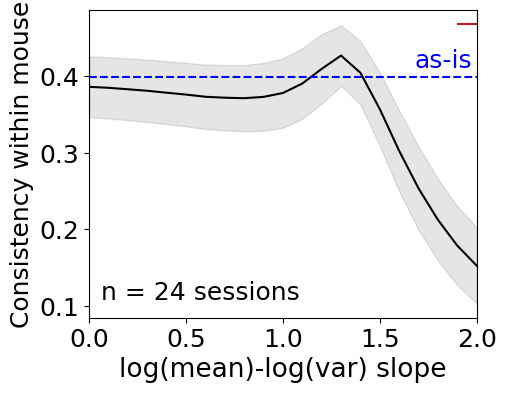

In [61]:
# RSA within session (without diagonal)

similarity_type = 'cos_sim'

save_file_name = 'RSM_corr_withinsess_dg75_250_all7_' + similarity_type + '.pickle' # include as-is, trial combination, RSM within sessions, use spike count, include session 42, spike count constant modified, exclude diagonal
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_all['list_corr_withinsess3'].copy()
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[bool_sess]
list_corr_withinsess3 = list_corr_withinsess3[bool_sess]

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(0, 2))
list_errs_corr_withinsess = sem(np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=0, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_withinsess = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[:, slope_ind, :, corr_ind].mean(axis=1), nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.84, height+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\dg75_250_RSA_within_nodiag.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\dg75_250_RSA_within_nodiag.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\sg_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_within_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_within_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 14h

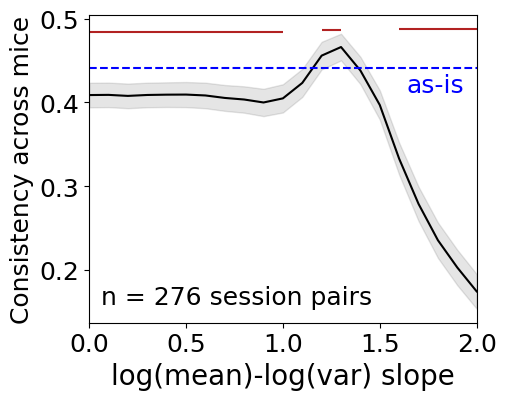

In [63]:
# RSA across sessions (without diagonal)
similarity_type = 'cos_sim'

save_file_name = 'RSM_dg75_250_all_allneu7_' + similarity_type + '.pickle' # trial order matched, use spike count, all sessions, remove gratings in variable names, spike count constant modified, exclude diagonal
with open(save_file_name, 'rb') as f:
    RSM_all = pickle.load(f)
    list_corr_sesspair_asis = RSM_all['list_corr_sesspair_asis'].copy()
    list_corr_sesspair2 = RSM_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude sessions that have invalid times or no V1 units
bool_sess = [~np.isin(sess_ind, np.concatenate([list_invalid_sess_visp['drifting_gratings_75_repeats'], [48, 49]])) and ~np.isin(sess_id, brain_observatory_sessid) for sess_ind, sess_id in enumerate(list_sess_ids)]
num_sess = int((1 + np.sqrt(1 + 8*list_corr_sesspair_asis.shape[0])) / 2) # solution of nC2 = shape[0]
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_sess = np.all(np.isin(sess_pairs, np.where(bool_sess)[0]), axis=1)
list_corr_sesspair_asis = list_corr_sesspair_asis[mask_sess]
list_corr_sesspair2 = list_corr_sesspair2[mask_sess]

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=0)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=0, ddof=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis[:, corr_ind]), c='b', linestyle='--')

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis[:, corr_ind], list_corr_sesspair2[:, slope_ind, corr_ind]))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\dg75_250_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\dg75_250_RSA_across_nodiag.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\dg75_250_RSA_across_nodiag.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\sg_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\sg_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_across_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\sg_RSA_across_interval.png', dpi=300, bbox_inches='tight')
plt.show()